## Cross-model results (CLAY / AlphaEarth)

Loads prediction parquets, JSON metrics, and CSV results to generate comparison plots.
- **Layout:** Experiment folders contain analysis subdirectories with standardized artifact names.
- **Kernel:** Requires `pandas`, `pyarrow`, `matplotlib`, and `seaborn`.

In [6]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110


def resolve_results_dir() -> Path:
    """Find `results_analysis` when cwd is thesis root, this folder, or a subfolder."""
    start = Path.cwd().resolve()
    if start.name == "results_analysis":
        return start
    for base in [start, *start.parents]:
        cand = base / "results_analysis"
        if cand.is_dir():
            return cand
    raise FileNotFoundError(
        "Could not find `results_analysis`. Open/run from the thesis tree or cd into results_analysis."
    )


RESULTS_DIR = resolve_results_dir()
print("RESULTS_DIR =", RESULTS_DIR)

# Consistent ordering in plots (unknown experiments sort last)
EXPERIMENT_ORDER = ["clay2010", "clay2020", "alphaearth2020"]
ANALYSIS_ORDER = ["analysis_ageb", "analysis_muni_rollup", "analysis_muni_direct"]


def _rank(values: pd.Series, order: list[str]) -> pd.Series:
    m = {name: i for i, name in enumerate(order)}
    return values.map(m).fillna(len(order) + 1)

RESULTS_DIR = /Users/henrychen/Desktop/CS-Econ Thesis/results_analysis


## Discover artifacts

In [7]:
parquet_paths = sorted(RESULTS_DIR.rglob("*.parquet"))
json_paths = sorted(RESULTS_DIR.rglob("metrics_overall*.json"))
state_csv_paths = sorted(RESULTS_DIR.rglob("metrics_by_state*.csv"))

print(f"Parquet files: {len(parquet_paths)}")
for p in parquet_paths:
    print(" ", p.relative_to(RESULTS_DIR))

# Count artifacts by top-level experiment folder
rows = []
for kind, paths in [
    ("parquet", parquet_paths),
    ("metrics_json", json_paths),
    ("metrics_by_state_csv", state_csv_paths),
]:
    for p in paths:
        rel = p.relative_to(RESULTS_DIR)
        exp = rel.parts[0] if len(rel.parts) > 1 else "root"
        rows.append({"experiment": exp, "kind": kind})
if rows:
    ct = (
        pd.DataFrame(rows)
        .groupby(["experiment", "kind"], observed=False)
        .size()
        .unstack(fill_value=0)
        .astype(int)
    )
    display(ct)

Parquet files: 12
  alphaearth2020/analysis_ageb/predictions_oof_emb.parquet
  alphaearth2020/analysis_muni_direct/predictions_oof_emb.parquet
  alphaearth2020/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2010/analysis_ageb/predictions_oof_emb.parquet
  clay2010/analysis_muni_direct/predictions_oof_emb.parquet
  clay2010/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2020/analysis_ageb/predictions_oof_emb.parquet
  clay2020/analysis_muni_direct/predictions_oof_emb.parquet
  clay2020/analysis_muni_rollup/predictions_oof_emb.parquet
  clay2020/cross_temporal/predictions_baseline_2010_2020_cv.parquet
  clay2020/cross_temporal/predictions_baseline_delta_2020_cv.parquet
  clay2020/cross_temporal/predictions_transfer_2010_to_2020.parquet


kind,metrics_by_state_csv,metrics_json,parquet
experiment,,,
alphaearth2020,3,3,3
clay2010,3,3,3
clay2020,6,6,6


## Overall metrics (Ridge vs XGBoost)

Visualizes aggregated metrics from `metrics_overall_*.json` as bar charts.

In [8]:
def load_metrics_overall_rows(paths: list[Path]) -> pd.DataFrame:
    rows: list[dict] = []
    for path in paths:
        with open(path) as f:
            doc = json.load(f)
        rel = path.relative_to(RESULTS_DIR)
        parts = rel.parts
        experiment = parts[0] if len(parts) > 1 else "root"
        subpath = "/".join(parts[1:-1]) if len(parts) > 2 else ""
        metrics = doc.get("metrics") or {}
        for model_name, m in metrics.items():
            rows.append(
                {
                    "json_path": str(rel),
                    "experiment": experiment,
                    "analysis": subpath or "(top)",
                    "target": doc.get("target"),
                    "experiment_type": doc.get("experiment"),
                    "unit_name": doc.get("unit_name"),
                    "model": model_name,
                    "r2": m.get("r2"),
                    "mae": m.get("mae"),
                    "rmse": m.get("rmse"),
                    "n": m.get("n"),
                }
            )
    return pd.DataFrame(rows)


metrics_df = load_metrics_overall_rows(json_paths)
if metrics_df.empty:
    print("No metrics_overall*.json found yet.")
else:
    metrics_df = metrics_df.copy()
    metrics_df["label"] = metrics_df["experiment"] + " / " + metrics_df["analysis"]
    metrics_df["_exp_rank"] = _rank(metrics_df["experiment"], EXPERIMENT_ORDER)
    metrics_df["_ana_rank"] = _rank(metrics_df["analysis"], ANALYSIS_ORDER)
    print(f"metrics rows: {len(metrics_df)}")
    display(
        metrics_df.sort_values(["_exp_rank", "_ana_rank", "model"]).drop(
            columns=["_exp_rank", "_ana_rank"], errors="ignore"
        )
    )

metrics rows: 24


,json_path,experiment,analysis,target,experiment_type,unit_name,model,r2,mae,rmse,n,label
6,clay2010/analysis_ageb/metrics_overall_emb.json,clay2010,analysis_ageb,log_popden,None,AGEBs,ridge,0.566523,0.632819,0.919557,53522,clay2010 / analysis_ageb
7,clay2010/analysis_ageb/metrics_overall_emb.json,clay2010,analysis_ageb,log_popden,None,AGEBs,xgboost,0.622888,0.579661,0.857691,53522,clay2010 / analysis_ageb
10,clay2010/analysis_muni_rollup/metrics_overall_...,clay2010,analysis_muni_rollup,log_popden,None,municipios,ridge,0.708254,0.324563,0.427761,2456,clay2010 / analysis_muni_rollup
11,clay2010/analysis_muni_rollup/metrics_overall_...,clay2010,analysis_muni_rollup,log_popden,None,municipios,xgboost,0.691131,0.334528,0.440135,2456,clay2010 / analysis_muni_rollup
8,clay2010/analysis_muni_direct/metrics_overall_...,clay2010,analysis_muni_direct,log_popden,None,municipios,ridge,0.708712,0.324777,0.427346,2456,clay2010 / analysis_muni_direct
9,clay2010/analysis_muni_direct/metrics_overall_...,clay2010,analysis_muni_direct,log_popden,None,municipios,xgboost,0.692253,0.334317,0.439253,2456,clay2010 / analysis_muni_direct
12,clay2020/analysis_ageb/metrics_overall_emb.json,clay2020,analysis_ageb,log_popden,None,AGEBs,ridge,0.489940,0.657042,0.943932,106564,clay2020 / analysis_ageb
13,clay2020/analysis_ageb/metrics_overall_emb.json,clay2020,analysis_ageb,log_popden,None,AGEBs,xgboost,0.587918,0.580148,0.848442,106564,clay2020 / analysis_ageb
16,clay2020/analysis_muni_rollup/metrics_overall_...,clay2020,analysis_muni_rollup,log_popden,None,municipios,ridge,0.742164,0.289389,0.383820,2469,clay2020 / analysis_muni_rollup
17,clay2020/analysis_muni_rollup/metrics_overall_...,clay2020,analysis_muni_rollup,log_popden,None,municipios,xgboost,0.763411,0.279365,0.367666,2469,clay2020 / analysis_muni_rollup


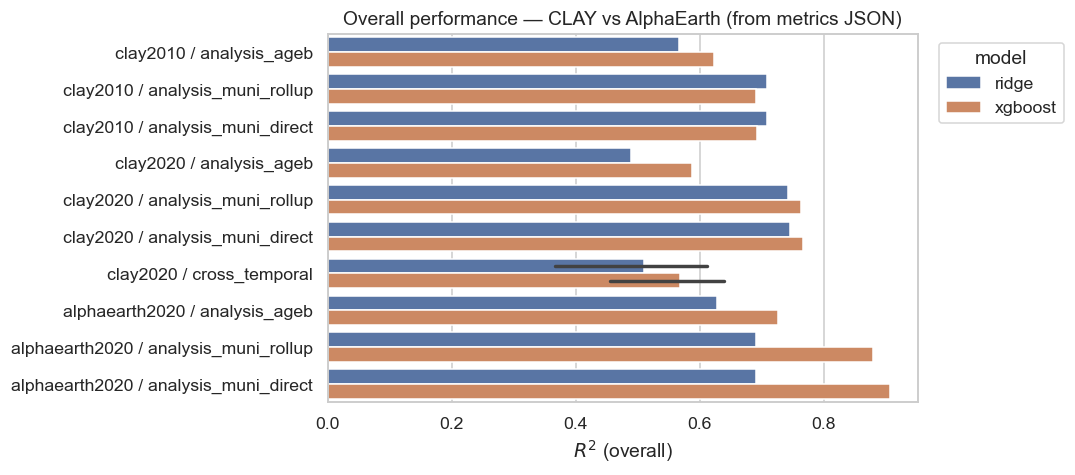

In [9]:
if not metrics_df.empty:
    plot_df = metrics_df[metrics_df["model"].isin(["ridge", "xgboost"])].copy()
    plot_df = plot_df.sort_values(["_exp_rank", "_ana_rank", "r2"])
    plot_df["label"] = pd.Categorical(
        plot_df["label"], categories=plot_df["label"].unique(), ordered=True
    )
    n_lab = plot_df["label"].nunique()
    fig_h = min(28, max(4.5, 0.36 * n_lab))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    sns.barplot(
        data=plot_df,
        y="label",
        x="r2",
        hue="model",
        hue_order=["ridge", "xgboost"],
        ax=ax,
    )
    ax.set_xlabel(r"$R^2$ (overall)")
    ax.set_ylabel("")
    ax.set_title("Overall performance — CLAY vs AlphaEarth (from metrics JSON)")
    ax.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Per-state $R^2$ (XGBoost) — AGEB scale

Compares AGEB-scale state-level metrics from `metrics_by_state_*.csv`.

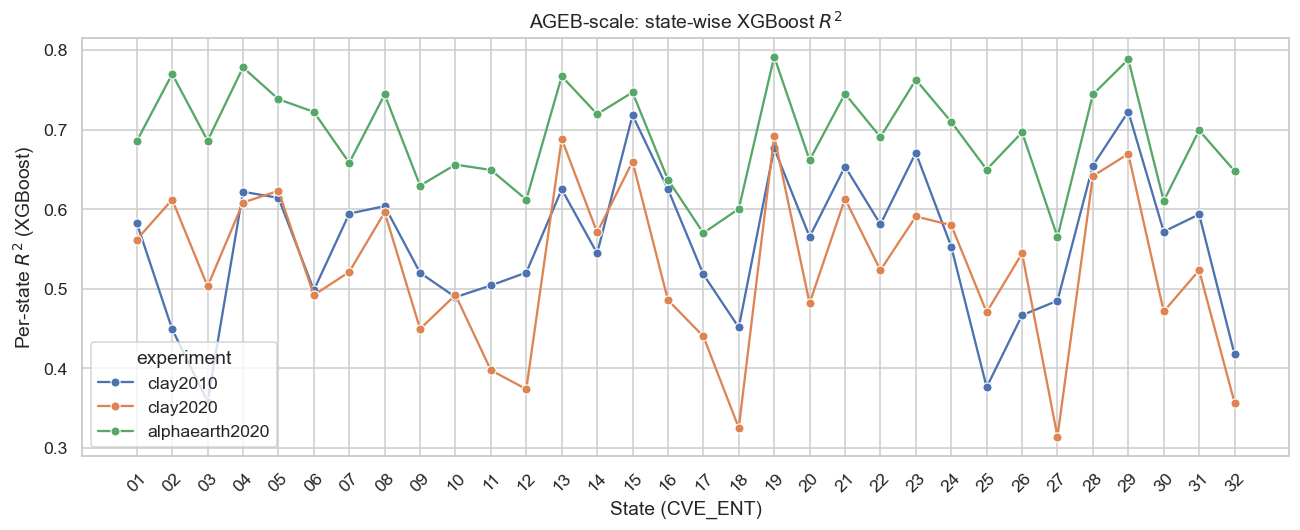

In [10]:
def load_state_metrics_ageb_xgb() -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for p in state_csv_paths:
        rel = p.relative_to(RESULTS_DIR)
        if "analysis_ageb" not in rel.parts:
            continue
        df = pd.read_csv(p)
        df = df[df["model"] == "xgboost"].copy()
        df["experiment"] = rel.parts[0]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


state_xgb = load_state_metrics_ageb_xgb()
if state_xgb.empty:
    print("No per-state CSV under analysis_ageb.")
else:
    state_xgb = state_xgb.copy()
    state_xgb["state"] = state_xgb["state"].astype(str).str.zfill(2)
    state_xgb["_hue_rank"] = _rank(state_xgb["experiment"], EXPERIMENT_ORDER)
    order = sorted(state_xgb["state"].unique())
    state_xgb["state_cat"] = pd.Categorical(state_xgb["state"], categories=order, ordered=True)
    fig, ax = plt.subplots(figsize=(12, 5))
    hue_ord = (
        state_xgb.sort_values("_hue_rank")["experiment"].drop_duplicates().tolist()
    )
    sns.lineplot(
        data=state_xgb,
        x="state_cat",
        y="r2",
        hue="experiment",
        hue_order=hue_ord,
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("State (CVE_ENT)")
    ax.set_ylabel(r"Per-state $R^2$ (XGBoost)")
    ax.set_title("AGEB-scale: state-wise XGBoost $R^2$")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Per-state $R^2$ (XGBoost) — Municipio scale

Compares rolled-up municipio-level metrics from `metrics_by_state_*.csv`.

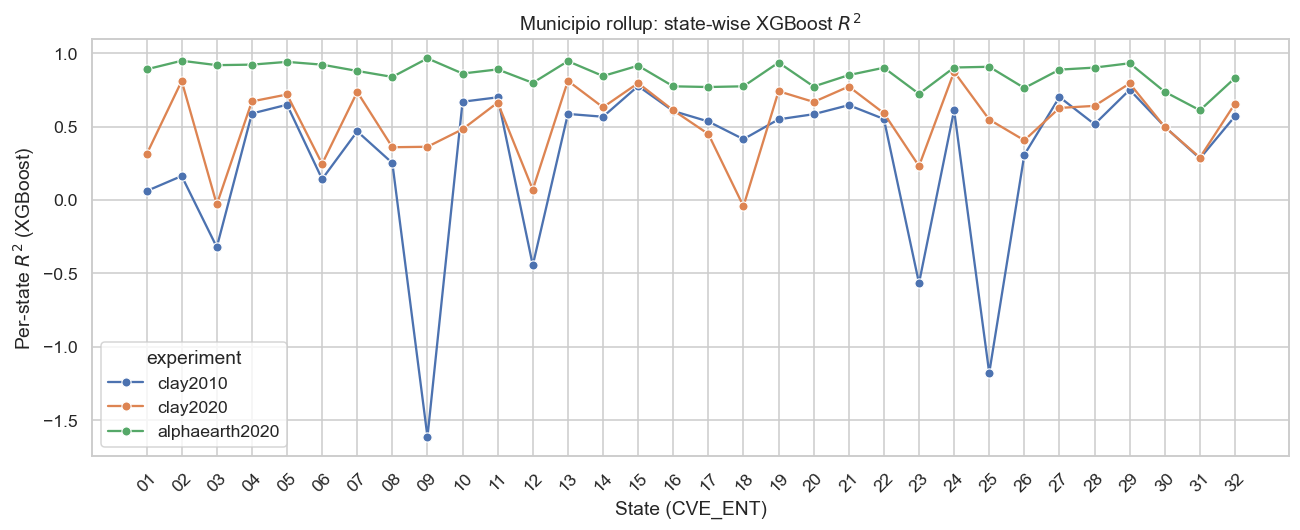

In [11]:
def load_state_metrics_subdir_xgb(subdir: str) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for p in state_csv_paths:
        rel = p.relative_to(RESULTS_DIR)
        if subdir not in rel.parts:
            continue
        df = pd.read_csv(p)
        df = df[df["model"] == "xgboost"].copy()
        df["experiment"] = rel.parts[0]
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


state_muni_roll = load_state_metrics_subdir_xgb("analysis_muni_rollup")
if state_muni_roll.empty:
    print("No per-state CSV under analysis_muni_rollup.")
else:
    g = state_muni_roll.copy()
    g["state"] = g["state"].astype(str).str.zfill(2)
    g["_hue_rank"] = _rank(g["experiment"], EXPERIMENT_ORDER)
    order = sorted(g["state"].unique())
    g["state_cat"] = pd.Categorical(g["state"], categories=order, ordered=True)
    fig, ax = plt.subplots(figsize=(12, 5))
    hue_ord = g.sort_values("_hue_rank")["experiment"].drop_duplicates().tolist()
    sns.lineplot(
        data=g,
        x="state_cat",
        y="r2",
        hue="experiment",
        hue_order=hue_ord,
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("State (CVE_ENT)")
    ax.set_ylabel(r"Per-state $R^2$ (XGBoost)")
    ax.set_title("Municipio rollup: state-wise XGBoost $R^2$")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Predictions vs Actuals and Residuals

Generates scatter plots and histograms from parquet predictions. Large datasets are subsampled. Adjust `PLOT_LIMIT` to limit output.

In [12]:
def normalize_pred_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def plot_pred_diagnostics(df: pd.DataFrame, title: str, n_sample: int = 8000, seed: int = 0) -> None:
    df = normalize_pred_frame(df)
    need = {"y", "pred_ridge", "pred_xgb"}
    if not need.issubset(df.columns):
        print(f"[skip] {title}: missing columns {need - set(df.columns)}")
        return
    rng = np.random.default_rng(seed)
    if len(df) > n_sample:
        idx = rng.choice(len(df), size=n_sample, replace=False)
        sub = df.iloc[idx]
    else:
        sub = df

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, col, name in zip(
        axes,
        ["pred_ridge", "pred_xgb"],
        ["Ridge", "XGBoost"],
    ):
        ax.scatter(sub["y"], sub[col], s=4, alpha=0.25, color="0.25")
        lims = [min(sub["y"].min(), sub[col].min()), max(sub["y"].max(), sub[col].max())]
        ax.plot(lims, lims, ls="--", color="C0", lw=1)
        ax.set_xlabel("y (log target)")
        ax.set_ylabel("prediction")
        ax.set_title(f"{name}: pred vs actual")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    resid = sub["pred_xgb"] - sub["y"]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(resid, bins=50, color="0.35", edgecolor="white")
    ax.set_title(f"{title} — XGBoost residual (n={len(sub):,})")
    ax.set_xlabel("pred − y")
    plt.tight_layout()
    plt.show()

## Calibration and Residual Distributions

Generates two 1x2 figures per source in `PUBLICATION_SOURCES`:
1. **Calibration:** Hexbin plot of $\ln(\text{actual})$ vs. $\ln(\text{predicted})$.
2. **Residuals:** Density histogram of OOF errors with a normal reference curve.

Exports figures to `deliverables/report/figs/`.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_alphaearth2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_alphaearth2020.png


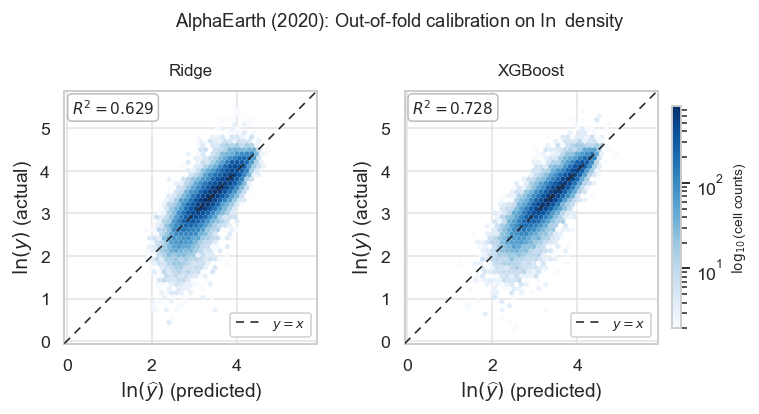

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_alphaearth2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_alphaearth2020.png


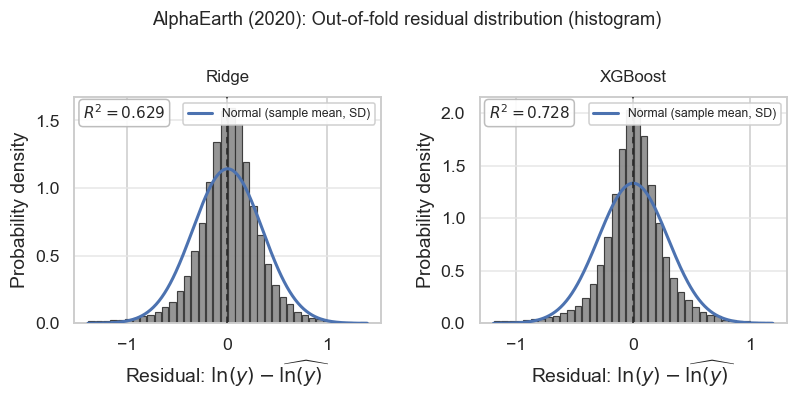

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2020.png


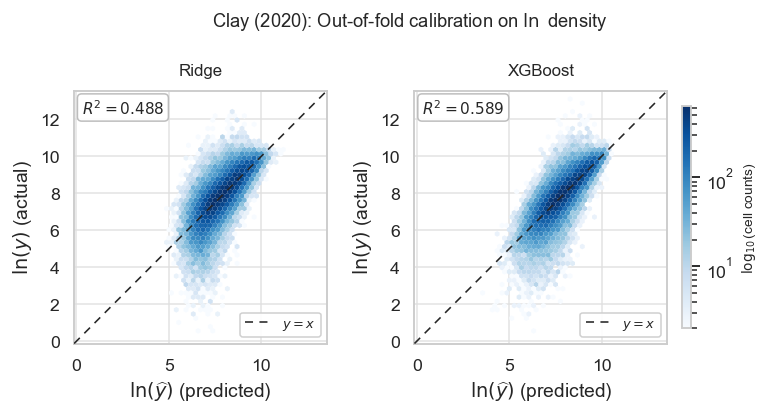

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2020.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2020.png


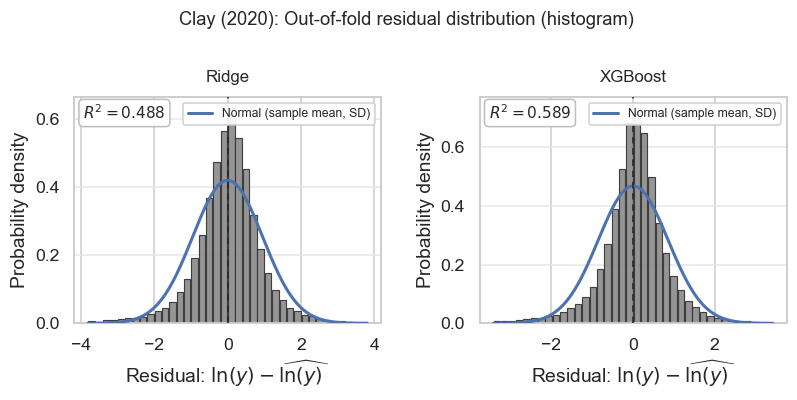

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2010.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_calibration_clay2010.png


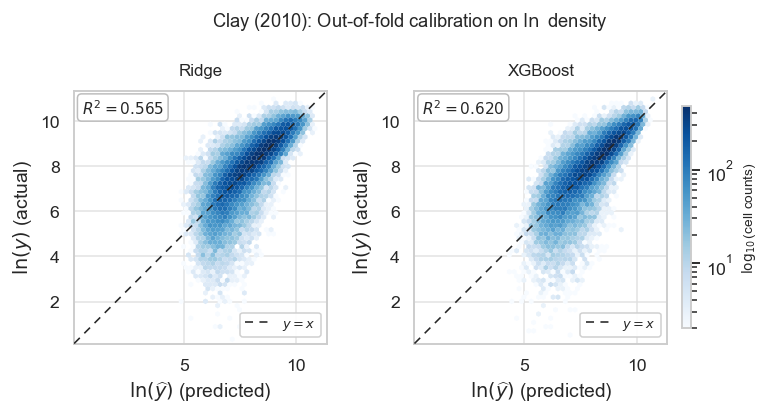

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2010.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/oof_residuals_clay2010.png


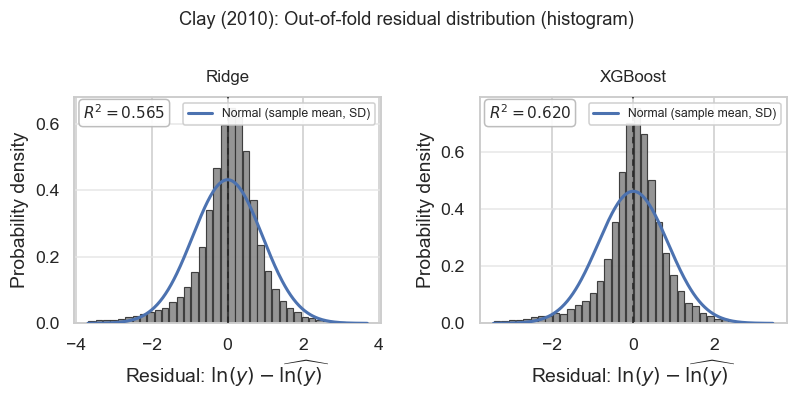

Figure directory: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs
Stem names: ``oof_calibration_<folder>`` and ``oof_residuals_<folder>`` (.pdf / .png). $R^2$ on panels is OOF $R^2$ on $\ln$-density (``sklearn``). Edit PUBLICATION_SOURCES / MAX_POINTS as needed.


In [13]:
# Three embedding × year pairs: two 1×2 figures each — hexbin calibration + bar-histogram residuals.
# Uses the notebook theme from earlier cells (no font / rc overrides in this cell).
# Saves each figure to ``deliverables/report/figs/`` (PDF + PNG) for the thesis.

from sklearn.metrics import r2_score

PUBLICATION_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020)", "alphaearth2020"),
    ("Clay (2020)", "clay2020"),
    ("Clay (2010)", "clay2010"),
]
MAX_POINTS = 40_000
RNG = np.random.default_rng(42)

# Thesis report figures (sibling of ``results_analysis/``)
CAL_RES_FIG_DIR = RESULTS_DIR.parent / "deliverables" / "report" / "figs"
CAL_RES_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _save_report_fig(fig, stem: str) -> None:
    """Write vector + raster copies next to ``report.tex``."""
    base = CAL_RES_FIG_DIR / stem
    fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(base.with_suffix(".png"), dpi=220, bbox_inches="tight")
    print("Saved:", base.with_suffix(".pdf"), "|", base.with_suffix(".png"))


def _norm_pdf(x: np.ndarray, mu: float, sig: float) -> np.ndarray:
    z = (x - mu) / sig
    return np.exp(-0.5 * z * z) / (sig * np.sqrt(2.0 * np.pi))


def _load_ageb_oof(folder: str) -> pd.DataFrame | None:
    p = RESULTS_DIR / folder / "analysis_ageb" / "predictions_oof_emb.parquet"
    if not p.is_file():
        return None
    return normalize_pred_frame(pd.read_parquet(p))


def _subsample(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) <= MAX_POINTS:
        return df
    idx = RNG.choice(len(df), size=MAX_POINTS, replace=False)
    return df.iloc[idx]


def _panel_limits(y: np.ndarray, pred_r: np.ndarray, pred_x: np.ndarray) -> tuple[float, float]:
    lo = float(min(y.min(), pred_r.min(), pred_x.min()))
    hi = float(max(y.max(), pred_r.max(), pred_x.max()))
    pad = 0.02 * (hi - lo)
    return lo - pad, hi + pad


def _residual_bin_edges(res: np.ndarray) -> np.ndarray:
    """Bin edges spanning most residual mass (symmetric around mean, capped at 8 sigma width)."""
    mu, sig = float(res.mean()), float(res.std(ddof=1))
    if sig < 1e-10:
        sig = 1.0
    span = min(float(res.max() - res.min()), 8.0 * sig)
    half = 0.5 * span
    lo, hi = mu - half, mu + half
    n_bins = 38
    return np.linspace(lo, hi, n_bins + 1)


def _r2_ln(yv: np.ndarray, pv: np.ndarray) -> float:
    """R² on the OOF log-density target (same scale as Table 8 ``R^2_ln``)."""
    return float(r2_score(yv, pv))


def _annotate_r2(ax, r2v: float) -> None:
    ax.text(
        0.03,
        0.97,
        rf"$R^2 = {r2v:.3f}$",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white", edgecolor="0.72", alpha=0.92),
        zorder=10,
    )


for lab, fold in PUBLICATION_SOURCES:
    d0 = _load_ageb_oof(fold)
    if d0 is None:
        print(f"[skip] missing: {fold}/analysis_ageb/predictions_oof_emb.parquet")
        continue
    d = _subsample(d0)
    if not all(c in d.columns for c in ["y", "pred_ridge", "pred_xgb"]):
        print(f"[skip] {fold}: expected y, pred_ridge, pred_xgb")
        continue

    y = d["y"].to_numpy(dtype=float)
    pr = d["pred_ridge"].to_numpy(dtype=float)
    px = d["pred_xgb"].to_numpy(dtype=float)
    lo, hi = _panel_limits(y, pr, px)
    r2_ridge = _r2_ln(y, pr)
    r2_xgb = _r2_ln(y, px)

    # --- Calibration: 1×2 hexbin ---
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.65))
    plt.subplots_adjust(left=0.07, right=0.98, top=0.78, bottom=0.15, wspace=0.32)
    mappable = None
    for ax, (mname, pv, r2v) in zip(
        axes,
        [("Ridge", pr, r2_ridge), ("XGBoost", px, r2_xgb)],
    ):
        hb = ax.hexbin(
            pv,
            y,
            gridsize=52,
            mincnt=2,
            extent=(lo, hi, lo, hi),
            cmap="Blues",
            linewidths=0.0,
            bins="log",
        )
        mappable = hb
        ax.plot(
            [lo, hi],
            [lo, hi],
            color="0.15",
            ls=(0, (5, 4)),
            lw=1.05,
            zorder=6,
            label=r"$y = x$",
        )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(r"$\ln(\widehat{y})$ (predicted)")
        ax.set_ylabel(r"$\ln(y)$ (actual)")
        ax.set_title(mname, fontsize=11, pad=10)
        ax.grid(True, color="0.88", zorder=0, alpha=0.9)
        ax.legend(loc="lower right", fontsize=8.5, framealpha=0.92)
        _annotate_r2(ax, r2v)

    cbar = fig.colorbar(mappable, ax=axes, shrink=0.88, pad=0.02, aspect=24)
    cbar.set_label(r"$\log_{10}$(cell counts)", fontsize=9)
    fig.suptitle(f"{lab}: Out-of-fold calibration on $\\ln$ density", fontsize=12, y=0.98)
    _save_report_fig(fig, f"oof_calibration_{fold}")
    plt.show()

    # --- Residuals: 1×2 bar histogram (density) + normal reference ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(7.2, 3.55))
    plt.subplots_adjust(left=0.08, right=0.98, top=0.76, bottom=0.18, wspace=0.32)
    for ax, (mname, pv, r2v) in zip(
        axes2,
        [("Ridge", pr, r2_ridge), ("XGBoost", px, r2_xgb)],
    ):
        res = y - pv
        bins = _residual_bin_edges(res)
        ax.hist(
            res,
            bins=bins,
            density=True,
            color="0.55",
            alpha=0.92,
            edgecolor="0.2",
            linewidth=0.75,
            rwidth=0.88,
            zorder=2,
        )
        mu, sig = float(res.mean()), float(res.std(ddof=1))
        if sig > 1e-10:
            xs = np.linspace(bins[0], bins[-1], 300)
            ax.plot(
                xs,
                _norm_pdf(xs, mu, sig),
                color="C0",
                lw=2.0,
                zorder=4,
                label="Normal (sample mean, SD)",
            )
        ax.axvline(0.0, color="0.15", ls=(0, (4, 3)), lw=1.05, zorder=5)
        ax.set_xlabel(r"Residual: $\ln(y) - \widehat{\ln(y)}$")
        ax.set_ylabel("Probability density")
        ax.set_title(mname, fontsize=11, pad=10)
        ax.legend(loc="upper right", fontsize=8, frameon=True, framealpha=0.92)
        ax.grid(True, axis="y", color="0.9", alpha=0.95, zorder=0)
        _annotate_r2(ax, r2v)

    fig2.suptitle(f"{lab}: Out-of-fold residual distribution (histogram)", fontsize=12, y=0.98)
    _save_report_fig(fig2, f"oof_residuals_{fold}")
    plt.show()

print(
    f"Figure directory: {CAL_RES_FIG_DIR.resolve()}\n"
    "Stem names: ``oof_calibration_<folder>`` and ``oof_residuals_<folder>`` (.pdf / .png). "
    "$R^2$ on panels is OOF $R^2$ on $\\ln$-density (``sklearn``). Edit PUBLICATION_SOURCES / MAX_POINTS as needed."
)


## Spatial Error Maps

Generates state-level choropleths using OOF metrics joined to Natural Earth polygons. Highlights systematic geographic error patterns.

- **`SPATIAL_MAP_MODEL`**: Selects `"ridge"` or `"xgboost"`.
- **`SHARED_METRIC_LIMITS`**: Toggles shared vs independent color scales.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_r2.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_r2.png


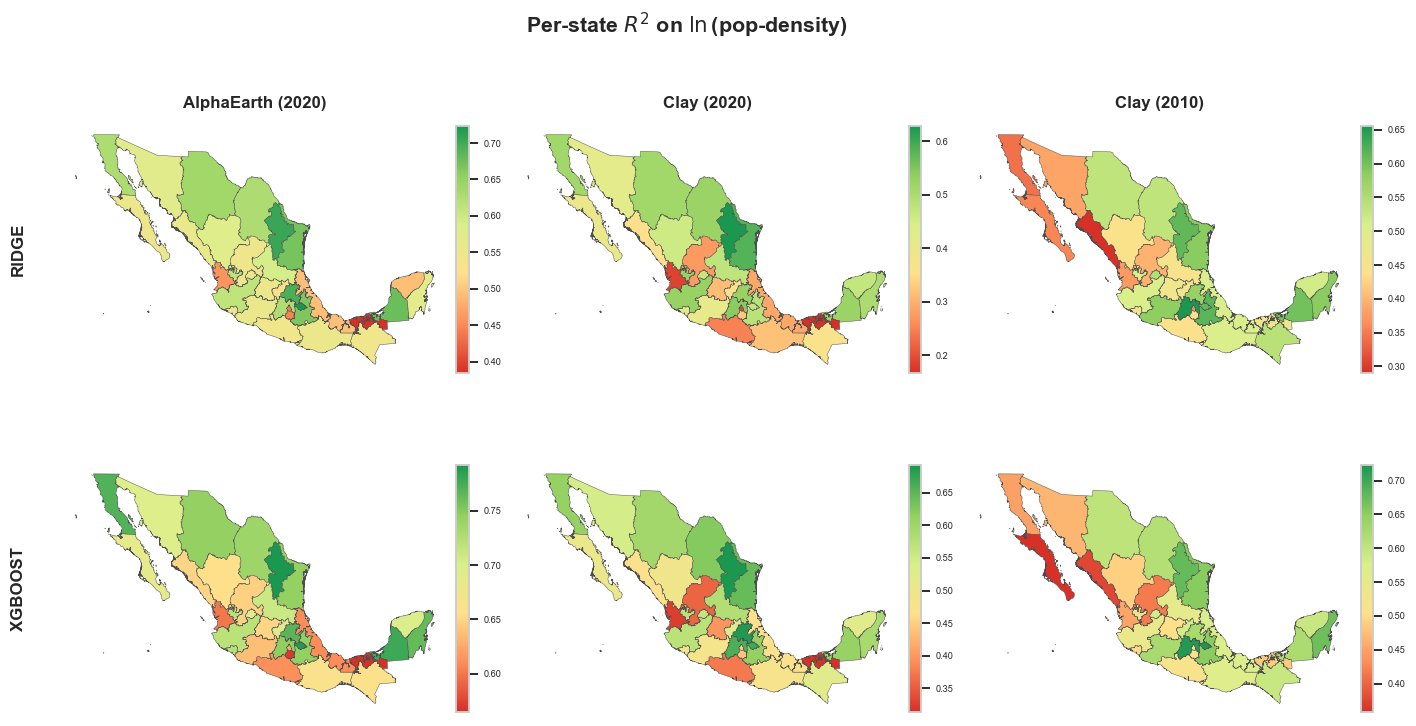

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_mae.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_mae.png


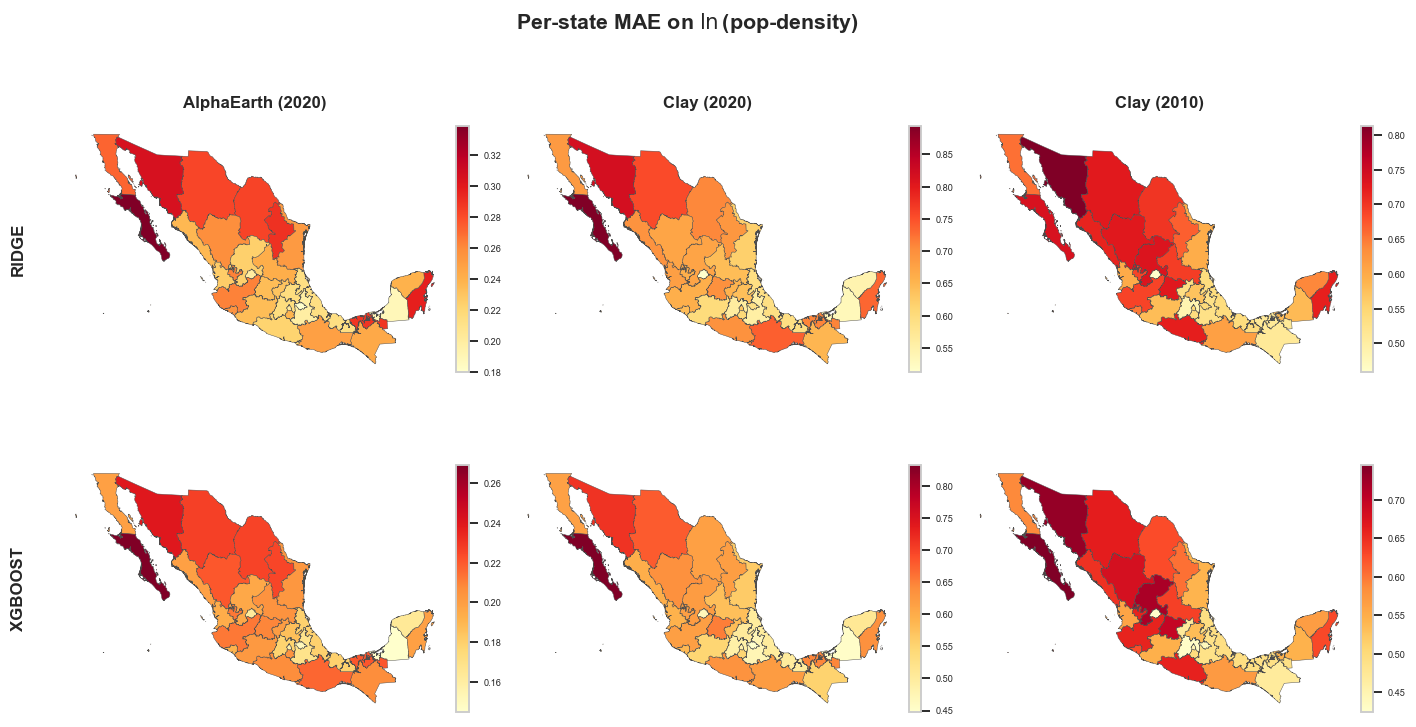

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, LinearSegmentedColormap

try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "Install geopandas for spatial maps (e.g. ``conda install geopandas`` or ``pip install geopandas``)."
    ) from e

# --- CONFIGURATION ---
_MAP_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020)", "alphaearth2020"),
    ("Clay (2020)", "clay2020"),
    ("Clay (2010)", "clay2010"),
]

_MODELS = ["ridge", "xgboost"]
SHARED_METRIC_LIMITS = False  

# Natural Earth URL and Mapping
_NATURAL_EARTH_ADMIN1_URL = (
    "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
)

_ISO2_TO_CVE: dict[str, str] = {
    "MX-AGU": "01", "MX-BCN": "02", "MX-BCS": "03", "MX-CAM": "04",
    "MX-COA": "05", "MX-COL": "06", "MX-CHP": "07", "MX-CHH": "08",
    "MX-DIF": "09", "MX-DUR": "10", "MX-GUA": "11", "MX-GRO": "12",
    "MX-HID": "13", "MX-JAL": "14", "MX-MEX": "15", "MX-MIC": "16",
    "MX-MOR": "17", "MX-NAY": "18", "MX-NLE": "19", "MX-OAX": "20",
    "MX-PUE": "21", "MX-QUE": "22", "MX-ROO": "23", "MX-SLP": "24",
    "MX-SIN": "25", "MX-SON": "26", "MX-TAB": "27", "MX-TAM": "28",
    "MX-TLA": "29", "MX-VER": "30", "MX-YUC": "31", "MX-ZAC": "32",
}

def _load_mx_states_geo() -> gpd.GeoDataFrame:
    local_shp = RESULTS_DIR / "mex_admin1.shp"
    if local_shp.exists():
        admin = gpd.read_file(local_shp)
        admin["CVE_ENT"] = admin["adm1_pcode"].str.replace("MX", "", regex=False)
    else:
        admin = gpd.read_file(_NATURAL_EARTH_ADMIN1_URL)
        admin = admin[admin["iso_a2"] == "MX"].copy()
        admin["CVE_ENT"] = admin["iso_3166_2"].map(_ISO2_TO_CVE)
    mx = admin[admin["CVE_ENT"].notna()].copy()
    try:
        mx = mx.to_crs(6372)
    except Exception:
        mx = mx.to_crs(4326)
    return mx

def _pick_model_rows(df: pd.DataFrame, model: str) -> pd.DataFrame:
    m = model.strip().lower()
    if m in {"xgb", "xgboost"}:
        return df[df["model"].astype(str).str.lower().isin(["xgboost", "xgb"])].copy()
    if m == "ridge":
        return df[df["model"].astype(str).str.lower() == "ridge"].copy()
    raise ValueError(f"Unknown model={model!r}")

def _collect_metrics_tables(model: str) -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for _lab, fold in _MAP_SOURCES:
        p = RESULTS_DIR / fold / "analysis_ageb" / "metrics_by_state_emb.csv"
        if not p.is_file(): continue
        raw = pd.read_csv(p)
        sel = _pick_model_rows(raw, model)
        if sel.empty: continue
        sel["CVE_ENT"] = sel["state"].astype(str).str.zfill(2)
        out[fold] = sel[["CVE_ENT", "r2", "mae", "n"]]
    return out

# --- SETUP DATA ---
mx_states = _load_mx_states_geo()
cmap_r2 = LinearSegmentedColormap.from_list("green_red", ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"])
cmap_mae = "YlOrRd"

_all_tables = {mod: _collect_metrics_tables(mod) for mod in _MODELS}

# Calculate limits for global scale fallback
all_r2 = np.concatenate([t["r2"].to_numpy(float) for tabs in _all_tables.values() for t in tabs.values()])
all_mae = np.concatenate([t["mae"].to_numpy(float) for tabs in _all_tables.values() for t in tabs.values()])
r2_lim = (float(np.nanmin(all_r2)), float(np.nanmax(all_r2)))
mae_lim = (float(np.nanmin(all_mae)), float(np.nanmax(all_mae)))

# --- PLOTTING ---

def _make_choropleth(metric: str, cmap, vlim: tuple, suptitle: str, save_stem: str):
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    
    # Adjusted top margin slightly to accommodate the new column titles
    plt.subplots_adjust(
        left=0.06, right=0.98, top=0.88, bottom=0.02,
        wspace=0.1, hspace=0.05 
    )

    for i, model in enumerate(_MODELS):
        tabs = _all_tables[model]
        for j, (lab, fold) in enumerate(_MAP_SOURCES):
            ax = axes[i, j]
            
            # Add Horizontal Subtitles (Column Titles) on the top row
            if i == 0:
                ax.set_title(lab, fontsize=11, fontweight='bold', pad=10)

            if fold not in tabs:
                ax.axis("off")
                continue

            tab = tabs[fold]
            merged = mx_states.merge(tab, on="CVE_ENT", how="left")
            vmin, vmax = (vlim if SHARED_METRIC_LIMITS else (float(tab[metric].min()), float(tab[metric].max())))

            merged.plot(
                column=metric, ax=ax, cmap=cmap,
                vmin=vmin, vmax=vmax, legend=False,
                edgecolor="0.3", linewidth=0.3,
                missing_kwds={"color": "0.95", "edgecolor": "0.7", "linewidth": 0.2},
            )

            # Independent colorbars
            if not SHARED_METRIC_LIMITS:
                sm = cm.ScalarMappable(norm=Normalize(vmin, vmax), cmap=cmap)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
                cbar.ax.tick_params(labelsize=6)

            ax.axis("off")

        # Row labels (Model Names)
        axes[i, 0].text(
            -0.08, 0.5, model.upper(),
            transform=axes[i, 0].transAxes,
            rotation=90, va="center", ha="right", fontsize=11, fontweight='bold'
        )

    fig.suptitle(suptitle, fontsize=14, y=0.98, fontweight='bold')
    _save_report_fig(fig, save_stem)
    plt.show()

# --- RUN ---
_make_choropleth(
    metric="r2", 
    cmap=cmap_r2, 
    vlim=r2_lim, 
    suptitle=r"Per-state $R^2$ on $\ln$(pop-density)", 
    save_stem="spatial_state_r2"
)

_make_choropleth(
    metric="mae", 
    cmap=cmap_mae, 
    vlim=mae_lim, 
    suptitle=r"Per-state MAE on $\ln$(pop-density)", 
    save_stem="spatial_state_mae"
)

### Over/Under-Prediction by State
Choropleth maps of **mean bias** (mean residual = predicted − actual) per state, showing systematic over- and under-prediction patterns across embedding sources.

## Polygon-Level Population Density Map (Mexico City)
Visualize all CDMX census polygons (urban AGEBs) colored by ln(population density) on a viridis scale, comparing 2020 and 2010 census vintages side by side.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/polygon_density_cdmx.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/polygon_density_cdmx.png


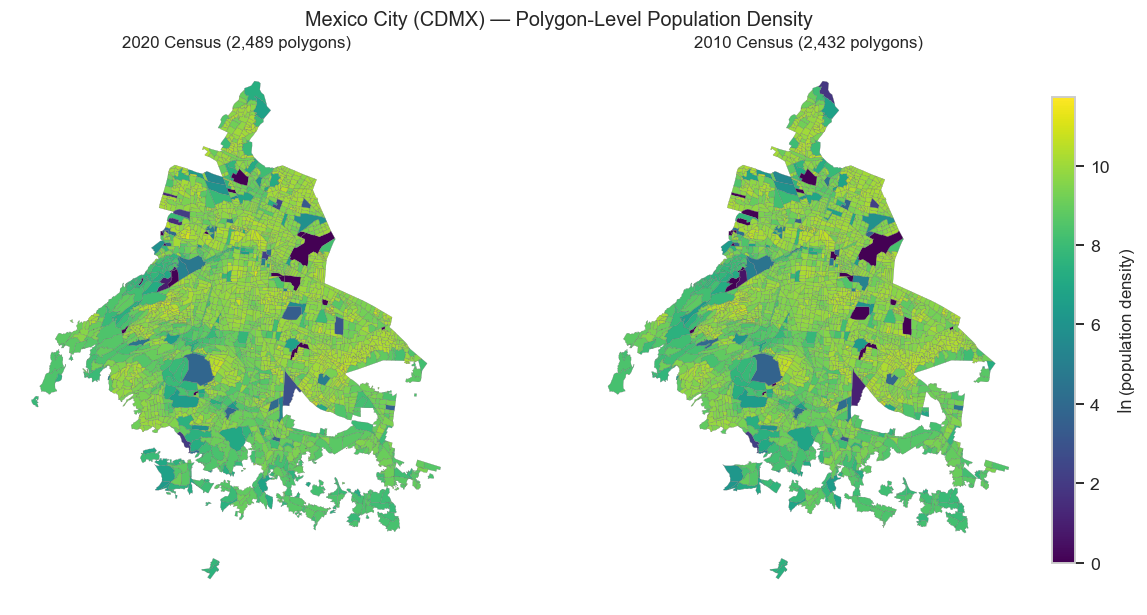

In [45]:
# --- CDMX polygon-level population density map (2020 vs 2010) ---

import geopandas as gpd
from matplotlib.colors import Normalize

_POLY_2020_PATH = RESULTS_DIR.parent / "alphaearth_src" / "data" / "geospatial" / "all_mexico_merged_2020.shp"
_POLY_2010_PATH = (
    RESULTS_DIR.parent / "clay_src" / "CLAY_mexico_thesis" / "CLAY_Inference_Project"
    / "embedding_extract" / "data" / "all_mexico_merged_2010.shp"
)

poly_2020 = gpd.read_file(_POLY_2020_PATH)
poly_2010 = gpd.read_file(_POLY_2010_PATH)

# Filter to CDMX (state code 09)
cdmx_2020 = poly_2020[poly_2020["CVE_ENT"] == "09"].copy()
poly_2010["CVE_ENT"] = poly_2010["CVEGEO"].str[:2]
cdmx_2010 = poly_2010[poly_2010["CVE_ENT"] == "09"].copy()

for df in [cdmx_2020, cdmx_2010]:
    df.geometry = df.geometry.to_crs(6372)

vmin = min(cdmx_2020["log_popden"].min(), cdmx_2010["log_popden"].min())
vmax = max(cdmx_2020["log_popden"].max(), cdmx_2010["log_popden"].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(left=0.02, right=0.90, wspace=0.06, top=0.88, bottom=0.05)

for ax, (poly, title) in zip(axes, [
    (cdmx_2020, f"2020 Census ({len(cdmx_2020):,} polygons)"),
    (cdmx_2010, f"2010 Census ({len(cdmx_2010):,} polygons)"),
]):
    poly.plot(
        column="log_popden", ax=ax, cmap="viridis",
        vmin=vmin, vmax=vmax,
        edgecolor="0.4", linewidth=0.15, legend=False,
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

sm = cm.ScalarMappable(norm=Normalize(vmin, vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02, shrink=0.85)
cbar.set_label(r"$\ln$(population density)", fontsize=11)

fig.suptitle("Mexico City (CDMX) — Polygon-Level Population Density", fontsize=13, y=0.95)
_save_report_fig(fig, "polygon_density_cdmx")
plt.show()


## CDMX Decadal Change: Actual vs. Predicted
Side-by-side comparison of actual Δln(population density) between 2010 and 2020 versus the best-predicted change (XGBoost with [emb_2010, Δemb] features) on matched AGEBs in Mexico City. Uses a diverging RdBu colormap: blue = growth, red = decline.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/cdmx_change_actual_vs_predicted.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/cdmx_change_actual_vs_predicted.png


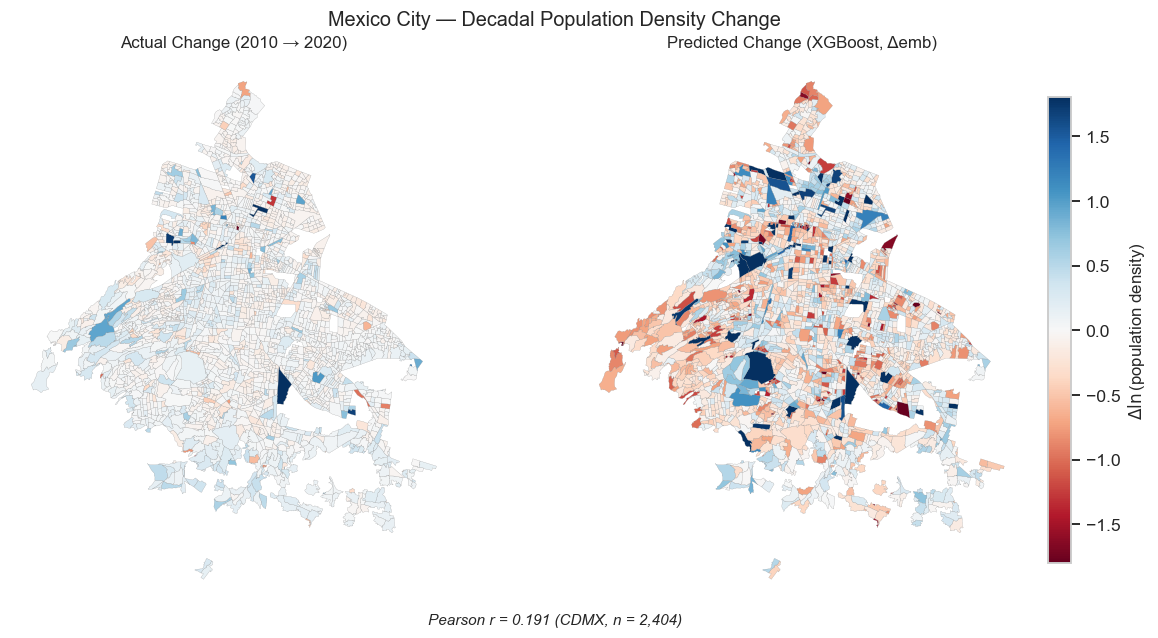

In [46]:
# --- CDMX decadal change: actual vs predicted ---
from matplotlib.colors import TwoSlopeNorm

_POLY_2010_PATH = (
    RESULTS_DIR.parent / "clay_src" / "CLAY_mexico_thesis" / "CLAY_Inference_Project"
    / "embedding_extract" / "data" / "all_mexico_merged_2010.shp"
)
_DELTA_PRED_PATH = (
    RESULTS_DIR / "clay2020" / "cross_temporal" / "predictions_baseline_delta_2020_cv.parquet"
)

poly_2010 = gpd.read_file(_POLY_2010_PATH).rename(columns={"log_popden": "log_popden_2010"})
delta_preds = pd.read_parquet(_DELTA_PRED_PATH)

merged = poly_2010[["CVEGEO", "log_popden_2010", "geometry"]].merge(
    delta_preds.rename(columns={"ageb_id": "CVEGEO", "y": "actual_2020",
                                 "pred_xgboost": "pred_2020_xgb"}),
    on="CVEGEO", how="inner"
)
merged["actual_delta"] = merged["actual_2020"] - merged["log_popden_2010"]
merged["pred_delta_xgb"] = merged["pred_2020_xgb"] - merged["log_popden_2010"]

cdmx = gpd.GeoDataFrame(
    merged[merged["state"] == "09"].copy(),
    geometry="geometry", crs=poly_2010.crs
).to_crs(6372)

abs_max = max(cdmx["actual_delta"].abs().quantile(0.98),
              cdmx["pred_delta_xgb"].abs().quantile(0.98))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(left=0.02, right=0.90, wspace=0.06, top=0.88, bottom=0.05)

cdmx.plot(column="actual_delta", ax=axes[0], cmap="RdBu", norm=norm,
          edgecolor="0.5", linewidth=0.12, legend=False)
axes[0].set_title("Actual Change (2010 → 2020)", fontsize=11)
axes[0].axis("off")

cdmx.plot(column="pred_delta_xgb", ax=axes[1], cmap="RdBu", norm=norm,
          edgecolor="0.5", linewidth=0.12, legend=False)
axes[1].set_title("Predicted Change (XGBoost, Δemb)", fontsize=11)
axes[1].axis("off")

sm = cm.ScalarMappable(norm=norm, cmap="RdBu")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02, shrink=0.85)
cbar.set_label(r"$\Delta\ln$(population density)", fontsize=11)

r = np.corrcoef(cdmx["actual_delta"], cdmx["pred_delta_xgb"])[0, 1]
fig.text(0.50, 0.02, f"Pearson r = {r:.3f} (CDMX, n = {len(cdmx):,})",
         ha="center", fontsize=10, style="italic")

fig.suptitle("Mexico City — Decadal Population Density Change", fontsize=13, y=0.95)
_save_report_fig(fig, "cdmx_change_actual_vs_predicted")
plt.show()


## Case Study: Actual vs. Predicted Population Density (City Level)
Compare actual and predicted ln(population density) for three city municipalities: **Monterrey** (R²=0.729), **Querétaro** (R²=0.697), and **Cancún** (R²=0.751). Uses AlphaEarth 2020 embeddings with XGBoost.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/case_study_actual_vs_predicted.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/case_study_actual_vs_predicted.png


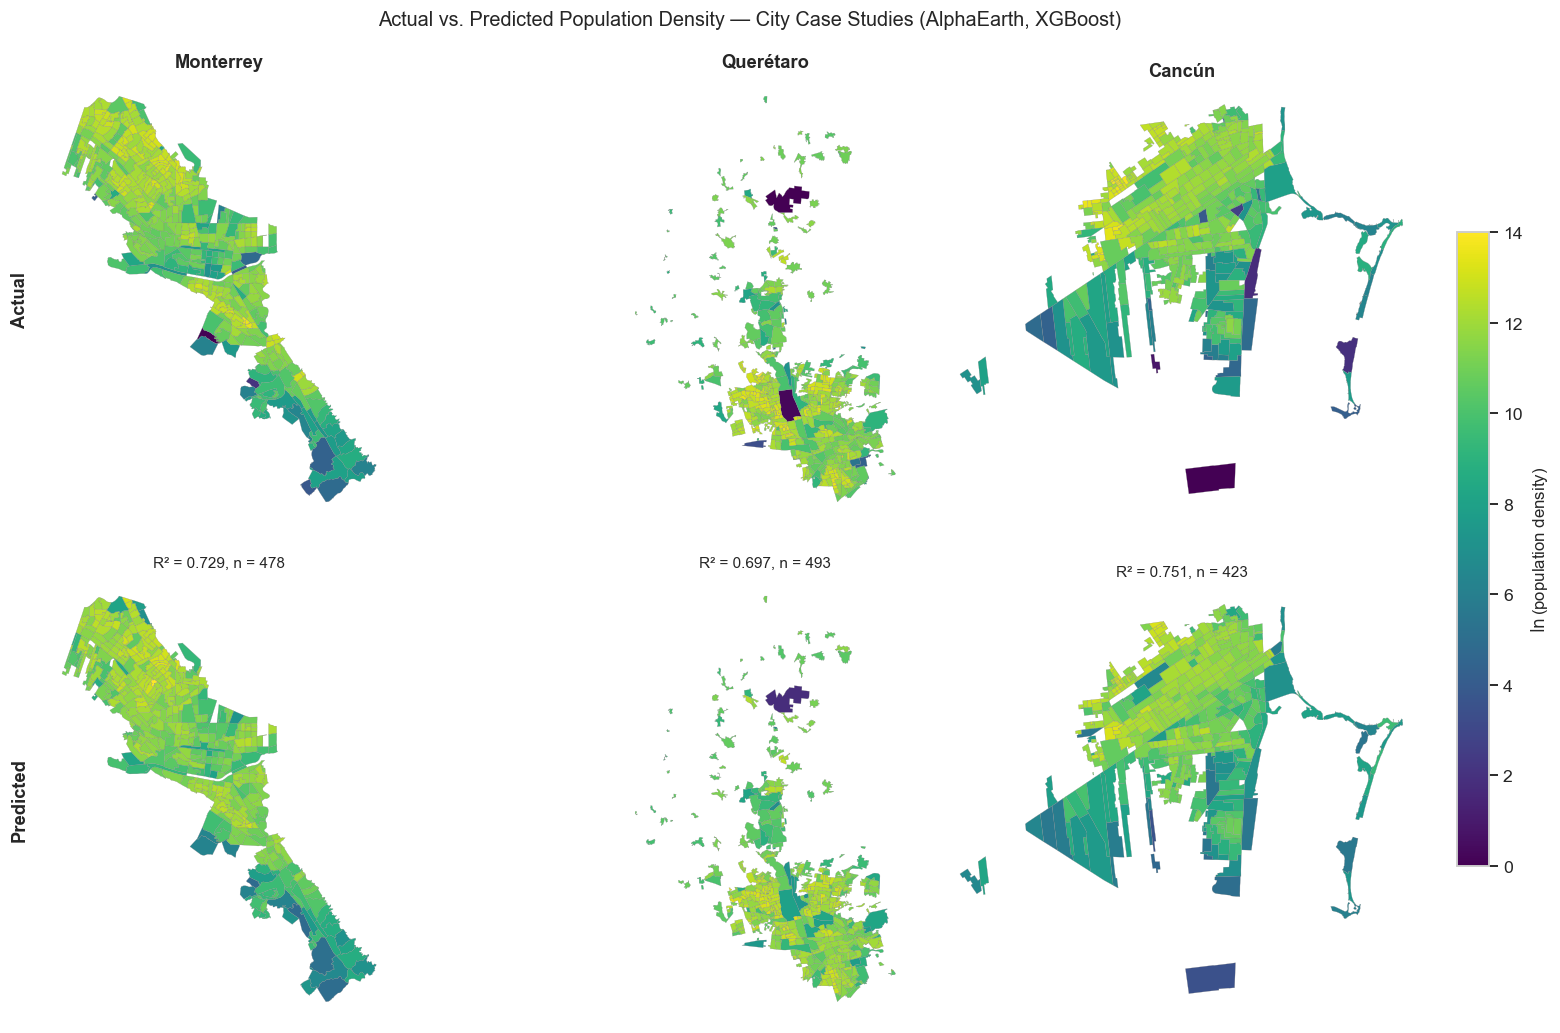

In [50]:
# --- Case study: actual vs predicted log pop density (city municipalities) ---

cs_preds = pd.read_parquet(RESULTS_DIR / "alphaearth2020" / "analysis_ageb" / "predictions_oof_emb.parquet")
poly_2020_full = gpd.read_file(
    RESULTS_DIR.parent / "alphaearth_src" / "data" / "geospatial" / "all_mexico_merged_2020.shp"
)

# City municipalities: (state_code, mun_code, display_name)
CS_CITIES = [("19", "039", "Monterrey"), ("22", "014", "Querétaro"), ("23", "005", "Cancún")]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.subplots_adjust(left=0.02, right=0.92, wspace=0.06, hspace=0.12, top=0.90, bottom=0.04)

for j, (st, mun, name) in enumerate(CS_CITIES):
    muni_poly = poly_2020_full[(poly_2020_full["CVE_ENT"] == st) & (poly_2020_full["CVE_MUN"] == mun)].copy()
    st_pred = cs_preds[cs_preds["state"] == st].copy()
    merged = muni_poly.merge(st_pred.rename(columns={"ageb_id": "CVEGEO"}), on="CVEGEO", how="inner")
    merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=poly_2020_full.crs).to_crs(6372)
    r2 = r2_score(merged["y"], merged["pred_xgb"])
    vmin = min(merged["y"].min(), merged["pred_xgb"].min())
    vmax = max(merged["y"].max(), merged["pred_xgb"].max())

    merged.plot(column="y", ax=axes[0, j], cmap="viridis",
                vmin=vmin, vmax=vmax, edgecolor="0.5", linewidth=0.15, legend=False)
    axes[0, j].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[0, j].axis("off")

    merged.plot(column="pred_xgb", ax=axes[1, j], cmap="viridis",
                vmin=vmin, vmax=vmax, edgecolor="0.5", linewidth=0.15, legend=False)
    axes[1, j].set_title(f"R² = {r2:.3f}, n = {len(merged):,}", fontsize=10)
    axes[1, j].axis("off")

axes[0, 0].text(-0.05, 0.5, "Actual", transform=axes[0, 0].transAxes,
                rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
axes[1, 0].text(-0.05, 0.5, "Predicted", transform=axes[1, 0].transAxes,
                rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")

sm = cm.ScalarMappable(norm=Normalize(0, 14), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, :], fraction=0.02, pad=0.02, shrink=0.8)
cbar.set_label(r"$\ln$(population density)", fontsize=11)

fig.suptitle("Actual vs. Predicted Population Density — City Case Studies (AlphaEarth, XGBoost)",
             fontsize=13, y=0.96)
_save_report_fig(fig, "case_study_actual_vs_predicted")
plt.show()


## Case Study: Temporal Change — City Level
Compare actual vs. predicted Δln(population density) for three city municipalities with the highest temporal Pearson r: **Querétaro** (r=0.567), **Cancún** (r=0.633), and **Aguascalientes** (r=0.678). Uses Clay [emb_2010, Δemb] with XGBoost.

Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/case_study_temporal_change.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/case_study_temporal_change.png


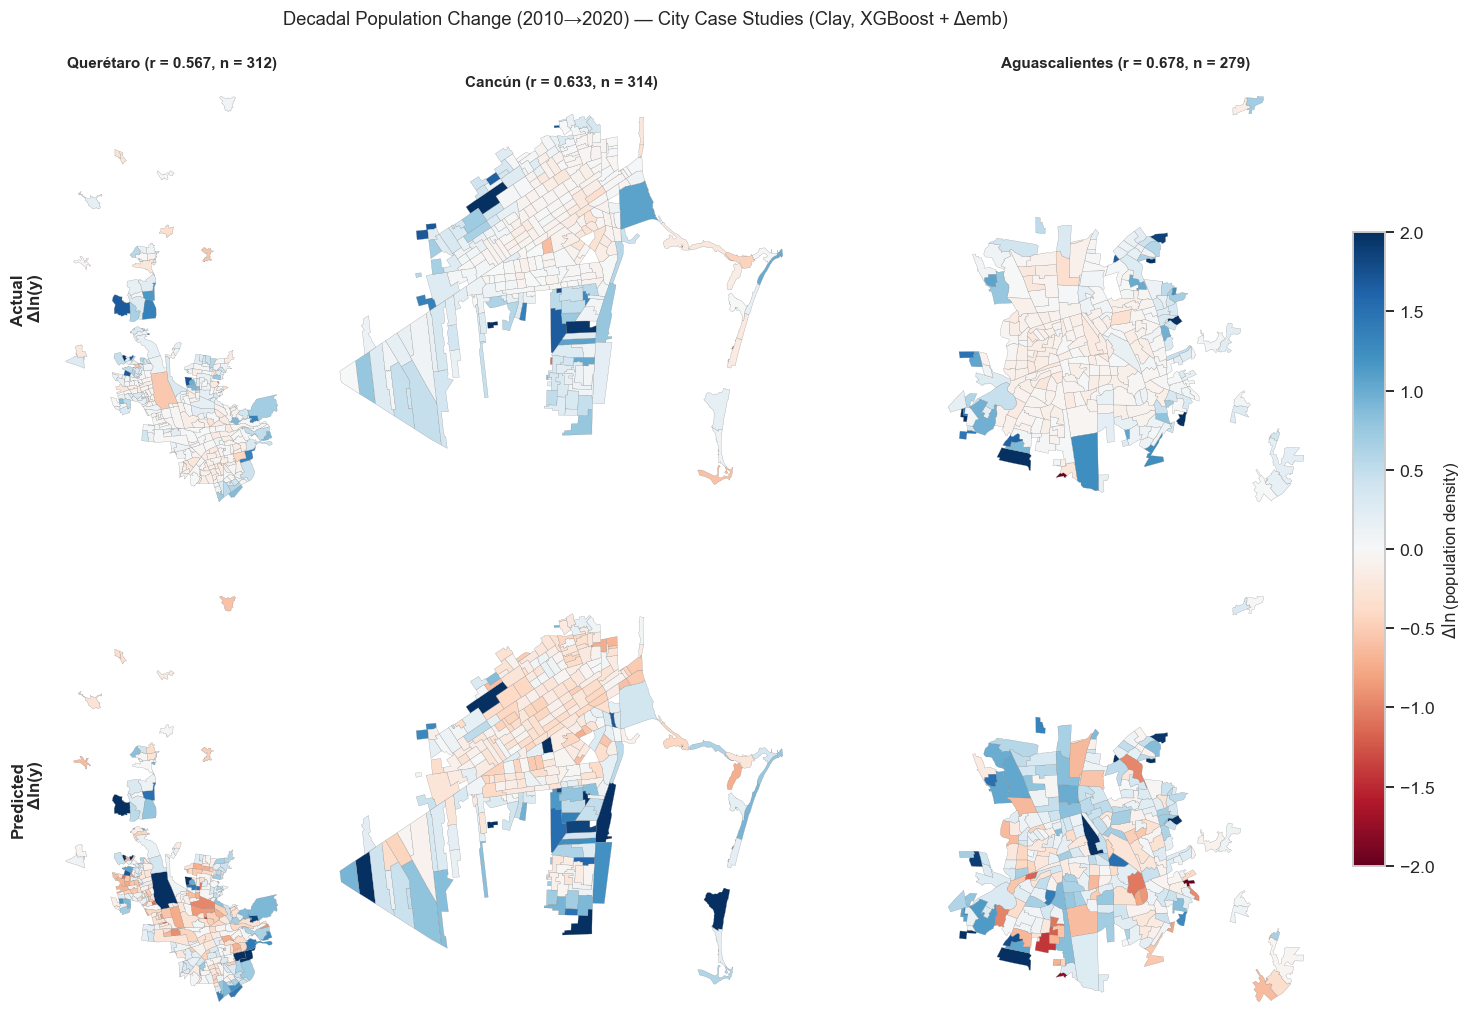

In [51]:
# --- Case study: temporal change for city municipalities ---
from matplotlib.colors import TwoSlopeNorm

_POLY_2010_PATH = (
    RESULTS_DIR.parent / "clay_src" / "CLAY_mexico_thesis" / "CLAY_Inference_Project"
    / "embedding_extract" / "data" / "all_mexico_merged_2010.shp"
)
_DELTA_PRED_PATH = RESULTS_DIR / "clay2020" / "cross_temporal" / "predictions_baseline_delta_2020_cv.parquet"

poly_2010_full = gpd.read_file(_POLY_2010_PATH).rename(columns={"log_popden": "log_popden_2010"})
delta_preds = pd.read_parquet(_DELTA_PRED_PATH)

temp_merged = poly_2010_full[["CVEGEO", "log_popden_2010", "geometry"]].merge(
    delta_preds.rename(columns={"ageb_id": "CVEGEO", "y": "actual_2020",
                                 "pred_xgboost": "pred_2020_xgb"}),
    on="CVEGEO", how="inner"
)
temp_merged["actual_delta"] = temp_merged["actual_2020"] - temp_merged["log_popden_2010"]
temp_merged["pred_delta"] = temp_merged["pred_2020_xgb"] - temp_merged["log_popden_2010"]

TEMP_CITIES = [("22", "014", "Querétaro"), ("23", "005", "Cancún"), ("01", "001", "Aguascalientes")]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.subplots_adjust(left=0.02, right=0.92, wspace=0.06, hspace=0.12, top=0.90, bottom=0.04)

for j, (st, mun, name) in enumerate(TEMP_CITIES):
    prefix = st + mun
    city = gpd.GeoDataFrame(
        temp_merged[temp_merged["CVEGEO"].str[:5] == prefix].copy(),
        geometry="geometry", crs=poly_2010_full.crs
    ).to_crs(6372)
    am = max(city["actual_delta"].abs().quantile(0.98), city["pred_delta"].abs().quantile(0.98))
    if am < 0.1: am = 1.0
    norm = TwoSlopeNorm(vmin=-am, vcenter=0, vmax=am)
    r_val = np.corrcoef(city["actual_delta"], city["pred_delta"])[0, 1]

    city.plot(column="actual_delta", ax=axes[0, j], cmap="RdBu", norm=norm,
              edgecolor="0.5", linewidth=0.15, legend=False)
    axes[0, j].set_title(f"{name} (r = {r_val:.3f}, n = {len(city):,})",
                          fontsize=10, fontweight="bold")
    axes[0, j].axis("off")

    city.plot(column="pred_delta", ax=axes[1, j], cmap="RdBu", norm=norm,
              edgecolor="0.5", linewidth=0.15, legend=False)
    axes[1, j].axis("off")

axes[0, 0].text(-0.05, 0.5, "Actual\nΔln(y)", transform=axes[0, 0].transAxes,
                rotation=90, va="center", ha="right", fontsize=11, fontweight="bold")
axes[1, 0].text(-0.05, 0.5, "Predicted\nΔln(y)", transform=axes[1, 0].transAxes,
                rotation=90, va="center", ha="right", fontsize=11, fontweight="bold")

sm = cm.ScalarMappable(norm=TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2), cmap="RdBu")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[:, :], fraction=0.02, pad=0.02, shrink=0.8)
cbar.set_label(r"$\Delta\ln$(population density)", fontsize=11)

fig.suptitle("Decadal Population Change (2010→2020) — City Case Studies (Clay, XGBoost + Δemb)",
             fontsize=12, y=0.96)
_save_report_fig(fig, "case_study_temporal_change")
plt.show()


Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_bias.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/spatial_state_bias.png


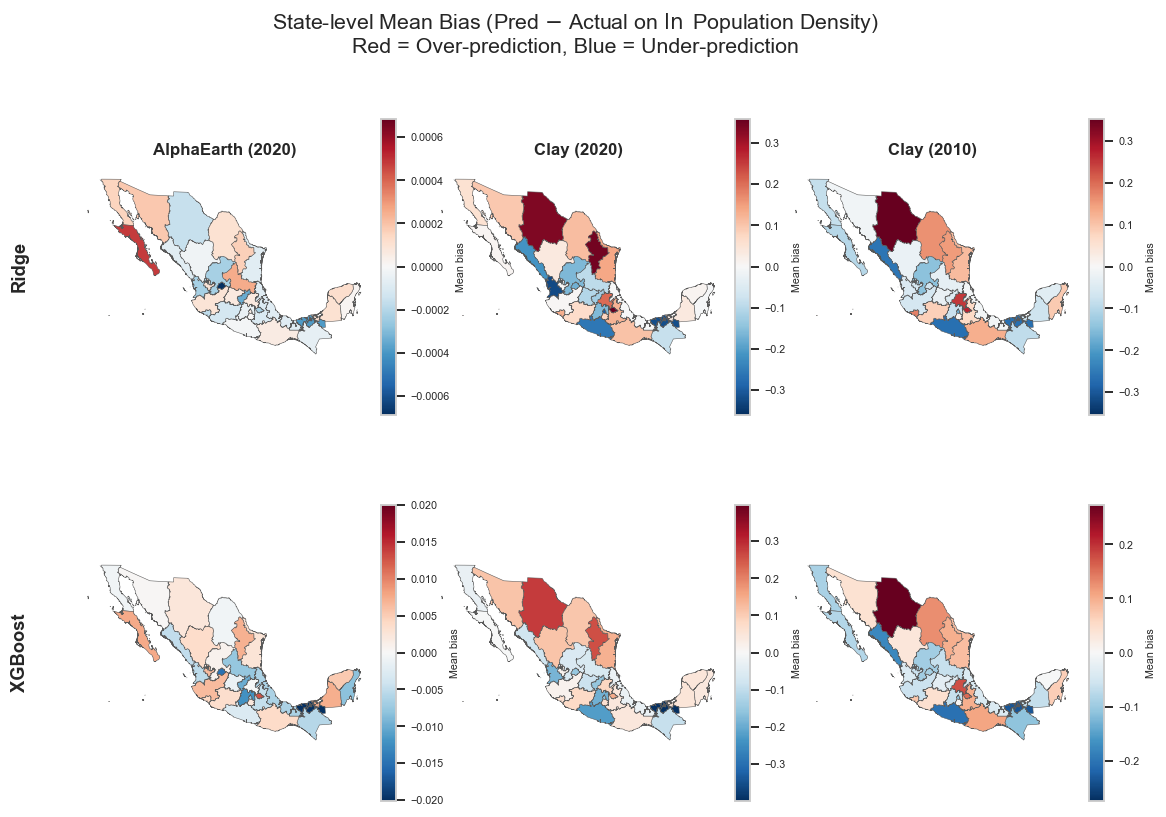



AlphaEarth (2020) — ridge
  Top 5 OVER-predicted:  [('03', 0.0005), ('24', 0.0003), ('26', 0.0002), ('19', 0.0002), ('02', 0.0002)]
  Top 5 UNDER-predicted: [('01', -0.0007), ('27', -0.0004), ('22', -0.0003), ('18', -0.0002), ('32', -0.0002)]

AlphaEarth (2020) — xgboost
  Top 5 OVER-predicted:  [('29', 0.0128), ('03', 0.0075), ('04', 0.0072), ('19', 0.0071), ('14', 0.0063)]
  Top 5 UNDER-predicted: [('27', -0.0201), ('01', -0.015), ('15', -0.0122), ('22', -0.0099), ('23', -0.0082)]

Clay (2020) — ridge
  Top 5 OVER-predicted:  [('29', 0.359499990940094), ('19', 0.3458999991416931), ('08', 0.3345000147819519), ('13', 0.20250000059604645), ('28', 0.1404000073671341)]
  Top 5 UNDER-predicted: [('18', -0.32350000739097595), ('27', -0.32019999623298645), ('09', -0.3001999855041504), ('12', -0.2587999999523163), ('25', -0.21410000324249268)]

Clay (2020) — xgboost
  Top 5 OVER-predicted:  [('08', 0.2791000008583069), ('19', 0.2556999921798706), ('29', 0.14910000562667847), ('28', 0.141800

In [42]:
from matplotlib.colors import TwoSlopeNorm

# --- 1. CONFIGURATION: EDIT YOUR TITLES HERE ---
# Map the internal keys (from BIAS_MODELS and _MAP_SOURCES) to your preferred display names.
TITLE_MAPPING = {
    # Row Titles (Models)
    "ridge": "Ridge",
    "xgboost": "XGBoost",
}

BIAS_MODELS = ["ridge", "xgboost"]
CMAP_BIAS = "RdBu_r"  # Red = over-predict, Blue = under-predict

# --- 2. BIAS CALCULATION ---
def _compute_state_bias(fold: str, model: str) -> pd.DataFrame | None:
    """Return per-state mean bias (pred − actual) from OOF predictions."""
    pred_path = RESULTS_DIR / fold / "analysis_ageb" / "predictions_oof_emb.parquet"
    if not pred_path.is_file():
        print(f"[skip bias] missing {pred_path.relative_to(RESULTS_DIR)}")
        return None
        
    df = pd.read_parquet(pred_path)
    pred_col = "pred_ridge" if model.lower() == "ridge" else "pred_xgb"
    
    if pred_col not in df.columns:
        print(f"[skip bias] column {pred_col!r} not in {fold}")
        return None
        
    # Residual = Prediction - Actual
    df["residual"] = df[pred_col] - df["y"]
    state_bias = (
        df.groupby("state")
        .agg(mean_bias=("residual", "mean"), n=("residual", "size"))
        .reset_index()
    )
    # Ensure state IDs are 2-digit strings for merging with mx_states
    state_bias["CVE_ENT"] = state_bias["state"].astype(str).str.zfill(2)
    return state_bias

# --- 3. FIGURE GENERATION ---
# 2 rows (Models) × 3 columns (Sources)
fig, axes = plt.subplots(len(BIAS_MODELS), len(_MAP_SOURCES), figsize=(12, 8))

# Adjust layout: 'left' increased to accommodate rotated row titles
plt.subplots_adjust(left=0.12, right=0.90, top=0.88, bottom=0.06, wspace=0.1, hspace=0.15)

for i, model in enumerate(BIAS_MODELS):
    for j, (lab, fold) in enumerate(_MAP_SOURCES):
        ax = axes[i, j]
        bias = _compute_state_bias(fold, model)

        if bias is None:
            ax.axis("off")
            if i == 0:
                ax.set_title(TITLE_MAPPING.get(lab, lab), fontsize=10)
            continue

        merged = mx_states.merge(bias, on="CVE_ENT", how="left")

        # Symmetric color scale centered on 0 (White = 0 bias)
        vabs = max(abs(bias["mean_bias"].min()), abs(bias["mean_bias"].max()))
        norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)

        merged.plot(
            column="mean_bias",
            ax=ax,
            cmap=CMAP_BIAS,
            norm=norm,
            legend=False,
            edgecolor="0.35",
            linewidth=0.35,
            missing_kwds={"color": "0.92", "edgecolor": "0.6", "linewidth": 0.25},
        )

        # Local colorbar for each panel
        sm = cm.ScalarMappable(norm=norm, cmap=CMAP_BIAS)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label("Mean bias", fontsize=7)
        cbar.ax.tick_params(labelsize=7)

        # Set Column Titles (Top Row only)
        if i == 0:
            col_title = TITLE_MAPPING.get(lab, lab)
            ax.set_title(col_title, fontsize=11, fontweight='bold', pad=10)
        
        ax.axis("off")

    # Set Row Titles (Y-Axis)
    row_title = TITLE_MAPPING.get(model.lower(), model.capitalize())
    axes[i, 0].text(
        -0.15, 0.5, # Position to the left of the map
        row_title,
        transform=axes[i, 0].transAxes,
        rotation=90, va="center", ha="right", 
        fontsize=12, fontweight='bold',
    )

# Global Figure Title
fig.suptitle(
    r"State-level Mean Bias (Pred $-$ Actual on $\ln$ Population Density)"
    "\nRed = Over-prediction, Blue = Under-prediction",
    fontsize=14, y=0.98,
)

# --- 4. EXPORT ---
_save_report_fig(fig, "spatial_state_bias")
plt.show()

# Print diagnostics
print("\n" + "=" * 70)
for lab, fold in _MAP_SOURCES:
    for model in BIAS_MODELS:
        bias = _compute_state_bias(fold, model)
        if bias is None:
            continue
        top5_over = bias.nlargest(5, "mean_bias")[["CVE_ENT", "mean_bias"]]
        top5_under = bias.nsmallest(5, "mean_bias")[["CVE_ENT", "mean_bias"]]
        print(f"\n{lab} — {model}")
        print(f"  Top 5 OVER-predicted:  {list(zip(top5_over['CVE_ENT'], top5_over['mean_bias'].round(4)))}")
        print(f"  Top 5 UNDER-predicted: {list(zip(top5_under['CVE_ENT'], top5_under['mean_bias'].round(4)))}")

## State-level Summary Table

Creates a comprehensive table of state characteristics (area, pop density, urbanization) and OOF $R^2$ scores across embeddings. Exports to PNG, HTML, and CSV in `deliverables/report/figs/`.

In [16]:
# --- State-level characteristics + OOF R²: all three embedding/year runs ---
STATE_SUMMARY_SOURCES: list[tuple[str, str]] = [
    ("Clay (2010)", "clay2010"),
    ("Clay (2020)", "clay2020"),
    ("AlphaEarth (2020)", "alphaearth2020"),
]
# Single source for label dispersion + polygon areas (Var(y), mean/median km²) — not repeated per experiment
STATE_SUMMARY_LABEL_FOLD = "clay2020"
STATE_SUMMARY_MODEL = globals().get("SPATIAL_MAP_MODEL", "ridge")

CVE_ENT_TO_ABBR = {
    f"{k:02d}": v
    for k, v in {
        1: "AGS",
        2: "BC",
        3: "BCS",
        4: "CAM",
        5: "COAH",
        6: "COL",
        7: "CHIS",
        8: "CHIH",
        9: "CDMX",
        10: "DGO",
        11: "GTO",
        12: "GRO",
        13: "HGO",
        14: "JAL",
        15: "MEX",
        16: "MICH",
        17: "MOR",
        18: "NAY",
        19: "NL",
        20: "OAX",
        21: "PUE",
        22: "QRO",
        23: "QROO",
        24: "SLP",
        25: "SIN",
        26: "SON",
        27: "TAB",
        28: "TAMPS",
        29: "TLAX",
        30: "VER",
        31: "YUC",
        32: "ZAC",
    }.items()
}

CVE_ENT_TO_STATE_NAME = {
    "01": "Aguascalientes",
    "02": "Baja California",
    "03": "Baja California Sur",
    "04": "Campeche",
    "05": "Coahuila",
    "06": "Colima",
    "07": "Chiapas",
    "08": "Chihuahua",
    "09": "Ciudad de México",
    "10": "Durango",
    "11": "Guanajuato",
    "12": "Guerrero",
    "13": "Hidalgo",
    "14": "Jalisco",
    "15": "México",
    "16": "Michoacán",
    "17": "Morelos",
    "18": "Nayarit",
    "19": "Nuevo León",
    "20": "Oaxaca",
    "21": "Puebla",
    "22": "Querétaro",
    "23": "Quintana Roo",
    "24": "San Luis Potosí",
    "25": "Sinaloa",
    "26": "Sonora",
    "27": "Tabasco",
    "28": "Tamaulipas",
    "29": "Tlaxcala",
    "30": "Veracruz",
    "31": "Yucatán",
    "32": "Zacatecas",
}

ENT_FROM_ABBR = {v: k for k, v in CVE_ENT_TO_ABBR.items()}
_METRIC_SUBCOLS = ["N", "frac_urban", "R²"]

_EMB_COMBINED = (
    RESULTS_DIR.parent
    / "alphaearth_src"
    / "data"
    / "embeddings"
    / "00_all_mexico_embeddings_combined.csv"
)


def _filter_metrics_model(raw_m: pd.DataFrame, model: str) -> pd.DataFrame:
    mod = str(model).strip().lower()
    if mod in {"xgb", "xgboost"}:
        return raw_m[raw_m["model"].astype(str).str.lower().isin({"xgboost", "xgb"})].copy()
    if mod == "ridge":
        return raw_m[raw_m["model"].astype(str).str.lower() == "ridge"].copy()
    raise ValueError(f"Unknown STATE_SUMMARY_MODEL={model!r}; use 'ridge' or 'xgboost'")


def _label_fold_polygon_frame(label_fold: str) -> pd.DataFrame | None:
    """AGEB rows for STATE_SUMMARY_LABEL_FOLD with state_abbr (for merging label/area stats)."""
    pred_path = RESULTS_DIR / label_fold / "analysis_ageb" / "predictions_oof_emb.parquet"
    if not pred_path.is_file():
        print(f"[label stats] missing {pred_path.relative_to(RESULTS_DIR)}")
        return None
    pred = normalize_pred_frame(pd.read_parquet(pred_path))
    pred["state"] = pred["state"].astype(str).str.zfill(2)
    pred["state_abbr"] = pred["state"].map(CVE_ENT_TO_ABBR)
    return pred[pred["state_abbr"].notna()].copy()


def _log_pop_density_by_state(pred_lf: pd.DataFrame | None) -> pd.Series | None:
    if pred_lf is None or pred_lf.empty:
        return None
    return pred_lf.groupby("state_abbr", sort=False)["y"].var()


def _mean_median_area_km2_by_state(pred_lf: pd.DataFrame | None) -> tuple[pd.Series | None, pd.Series | None]:
    if pred_lf is None or pred_lf.empty:
        return None, None
    if not _EMB_COMBINED.is_file():
        print(f"[note] mean/median area unavailable — missing:\n  {_EMB_COMBINED}")
        idx = pred_lf["state_abbr"].unique()
        na = pd.Series(np.nan, index=pd.Index(idx, name="state_abbr"))
        return na, na.copy()

    area = pd.read_csv(
        _EMB_COMBINED,
        usecols=["CVEGEO", "area_sqkm"],
        dtype={"CVEGEO": str},
    )
    merged = pred_lf.merge(
        area,
        left_on=pred_lf["ageb_id"].astype(str),
        right_on="CVEGEO",
        how="left",
    ).drop(columns=["CVEGEO"], errors="ignore")
    g = merged.groupby("state_abbr", sort=False)
    return g["area_sqkm"].mean(), g["area_sqkm"].median()


def _block_for_fold(fold: str) -> pd.DataFrame | None:
    pred_path = RESULTS_DIR / fold / "analysis_ageb" / "predictions_oof_emb.parquet"
    metrics_path = RESULTS_DIR / fold / "analysis_ageb" / "metrics_by_state_emb.csv"
    if not pred_path.is_file():
        print(f"[skip {fold}] missing {pred_path.relative_to(RESULTS_DIR)}")
        return None
    if not metrics_path.is_file():
        print(f"[skip {fold}] missing {metrics_path.relative_to(RESULTS_DIR)}")
        return None

    pred = normalize_pred_frame(pd.read_parquet(pred_path))
    pred["state"] = pred["state"].astype(str).str.zfill(2)
    pred["state_abbr"] = pred["state"].map(CVE_ENT_TO_ABBR)
    pred = pred[pred["state_abbr"].notna()].copy()
    pred["_urban_len13"] = pred["ageb_id"].astype(str).str.len().eq(13).astype(float)

    grouped = pred.groupby("state_abbr", sort=False)
    chars = pd.DataFrame(
        {
            "N": grouped.size(),
            "frac_urban": grouped["_urban_len13"].mean(),
        }
    )

    raw_m = pd.read_csv(metrics_path)
    sel_m = _filter_metrics_model(raw_m, STATE_SUMMARY_MODEL)
    if sel_m.empty:
        print(f"[skip {fold}] no metrics rows for model={STATE_SUMMARY_MODEL!r}")
        return None
    sel_m = sel_m.copy()
    sel_m["state_abbr"] = sel_m["state"].astype(str).str.zfill(2).map(CVE_ENT_TO_ABBR)
    r2 = sel_m.drop_duplicates("state_abbr").set_index("state_abbr")["r2"].rename("R²")
    chars = chars.join(r2, how="inner")
    return chars


pred_label = _label_fold_polygon_frame(STATE_SUMMARY_LABEL_FOLD)
log_pop_var = _log_pop_density_by_state(pred_label)
mean_area_s, median_area_s = _mean_median_area_km2_by_state(pred_label)

blocks: list[tuple[str, pd.DataFrame]] = []
for lab, fold in STATE_SUMMARY_SOURCES:
    b = _block_for_fold(fold)
    if b is None:
        continue
    missing = [c for c in _METRIC_SUBCOLS if c not in b.columns]
    if missing:
        print(f"[skip {fold}] incomplete columns {missing}")
        continue
    b = b[_METRIC_SUBCOLS]
    b.columns = pd.MultiIndex.from_product([[lab], _METRIC_SUBCOLS])
    blocks.append((lab, b))

if not blocks:
    print("No experiment blocks loaded — check analysis_ageb artifacts.")
else:
    out = pd.concat([df for _, df in blocks], axis=1)
    out.insert(
        0,
        "state_name",
        out.index.map(lambda abbr: CVE_ENT_TO_STATE_NAME.get(ENT_FROM_ABBR.get(abbr, ""), "")),
    )
    if log_pop_var is not None:
        out.insert(1, "log pop density", log_pop_var.reindex(out.index))
    else:
        out.insert(1, "log pop density", np.nan)

    _ma = mean_area_s.reindex(out.index) if mean_area_s is not None else np.nan
    _md = median_area_s.reindex(out.index) if median_area_s is not None else np.nan
    out.insert(2, "mean area (km²)", _ma)
    out.insert(3, "median area (km²)", _md)

    sort_key = ("Clay (2020)", "R²")
    if sort_key not in out.columns:
        r2_tuples = [c for c in out.columns if isinstance(c, tuple) and len(c) > 1 and c[1] == "R²"]
        sort_key = r2_tuples[0] if r2_tuples else None
    if sort_key is not None:
        out = out.sort_values(sort_key, ascending=False)

    out = out.reset_index(drop=True)

    caption = (
        f"{STATE_SUMMARY_MODEL}: single-column descriptors from {STATE_SUMMARY_LABEL_FOLD} polygons "
        "(Var(y), mean/median polygon area via merged AlphaEarth combined embeddings CSV); "
        "per-run N / frac_urban / R² from predictions_oof_emb + metrics_by_state_emb."
    )

    fmt_dict: dict = {
        "log pop density": "{:.3f}",
        "mean area (km²)": "{:.2f}",
        "median area (km²)": "{:.3f}",
    }
    for lab, _fold in STATE_SUMMARY_SOURCES:
        if (lab, "N") not in out.columns:
            continue
        fmt_dict[(lab, "N")] = "{:,}"
        fmt_dict[(lab, "frac_urban")] = "{:.3f}"
        fmt_dict[(lab, "R²")] = "{:.3f}"

    r2_cols = [
        c
        for c in out.columns
        if isinstance(c, tuple) and len(c) > 1 and c[1] == "R²"
    ]
    sty = out.style.format(fmt_dict, na_rep="").hide(axis="index")
    if r2_cols:
        _pool = out[r2_cols].to_numpy(dtype=float).ravel()
        _pool = _pool[np.isfinite(_pool)]
        if _pool.size:
            _lo, _hi = float(_pool.min()), float(_pool.max())
            if _lo == _hi:
                _hi = _lo + 1e-9
            sty = sty.background_gradient(subset=r2_cols, cmap="YlGn", vmin=_lo, vmax=_hi)
    sty = sty.set_caption(caption)

    _REPORT_FIG_DIR = RESULTS_DIR.parent / "deliverables" / "report" / "figs"
    _REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
    _model_slug = str(STATE_SUMMARY_MODEL).strip().lower().replace(" ", "_")
    _stem = f"state_summary_ageb_oof_{_model_slug}"
    _html_path = _REPORT_FIG_DIR / f"{_stem}.html"
    _html_path.write_text(sty.to_html(), encoding="utf-8")
    _csv_path = _REPORT_FIG_DIR / f"{_stem}.csv"
    _png_path = _REPORT_FIG_DIR / f"{_stem}.png"
    _flat = out.copy()

    def _csv_header(col):
        if isinstance(col, tuple):
            return " | ".join(str(x) for x in col if str(x) != "")
        return str(col)

    _flat.columns = [_csv_header(c) for c in _flat.columns]
    _flat.to_csv(_csv_path, encoding="utf-8", index=False)

    _saved_paths = [_html_path, _csv_path]
    try:
        import dataframe_image as dfi

        dfi.export(sty, _png_path, dpi=220, table_conversion="matplotlib")
        _saved_paths.append(_png_path)
    except ImportError:
        print(
            "[note] PNG skipped — install dataframe_image "
            "(e.g. ``pip install dataframe_image``)."
        )
    except Exception as _e:
        print(f"[warn] Could not save PNG {_png_path.name}: {_e}")

    print("Saved:", " | ".join(str(p) for p in _saved_paths))

    display(sty)


Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.html | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.csv | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/state_summary_ageb_oof_ridge.png


## State-Level R² vs. Data Characteristics

For each embedding source × model combination, scatter plots of per-state OOF $R^2$ against state-level characteristics (sample size, target variance, polygon area, urbanization), with Pearson r and p-value. Points labeled by state abbreviation.

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/899774498.py:90: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, p_val = stats.pearsonr(x, y)
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/899774498.py:91: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)


Saved: Clay (2010) / ridge


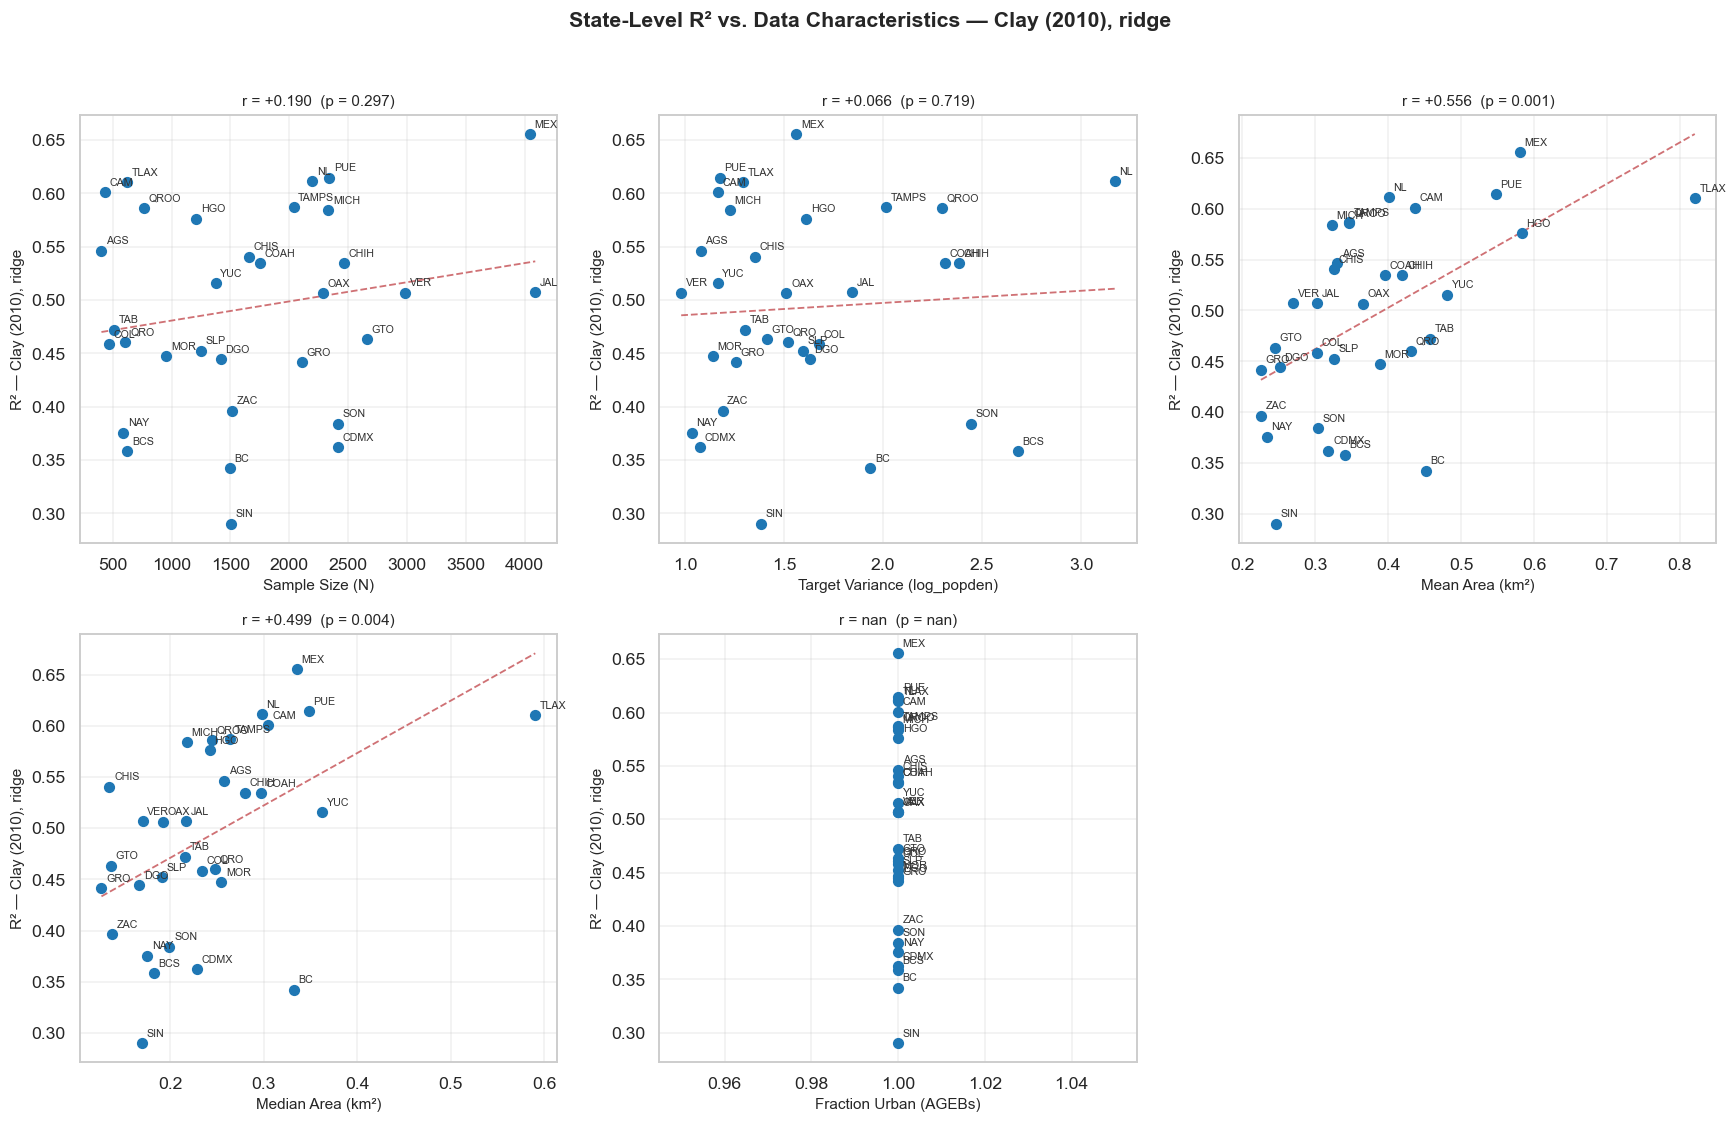

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/899774498.py:90: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, p_val = stats.pearsonr(x, y)
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/899774498.py:91: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(x, y, 1)


Saved: Clay (2010) / xgboost


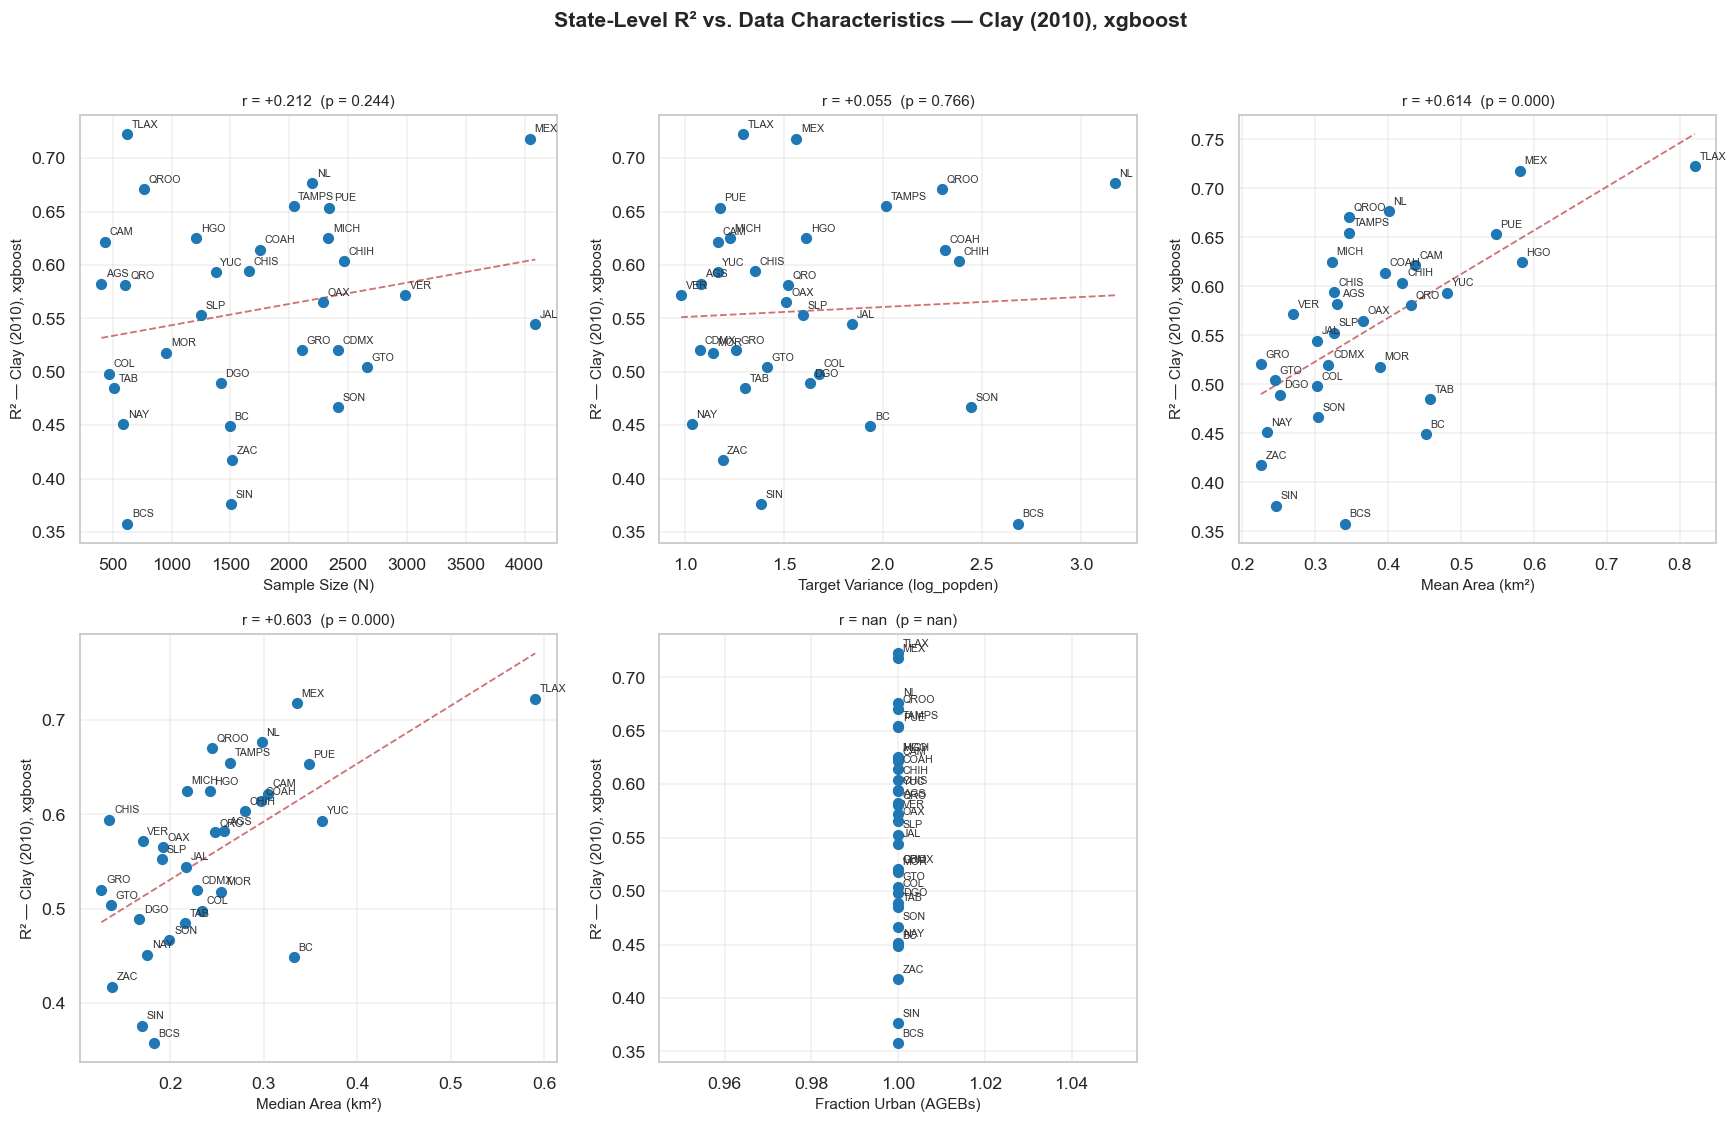

Saved: Clay (2020) / ridge


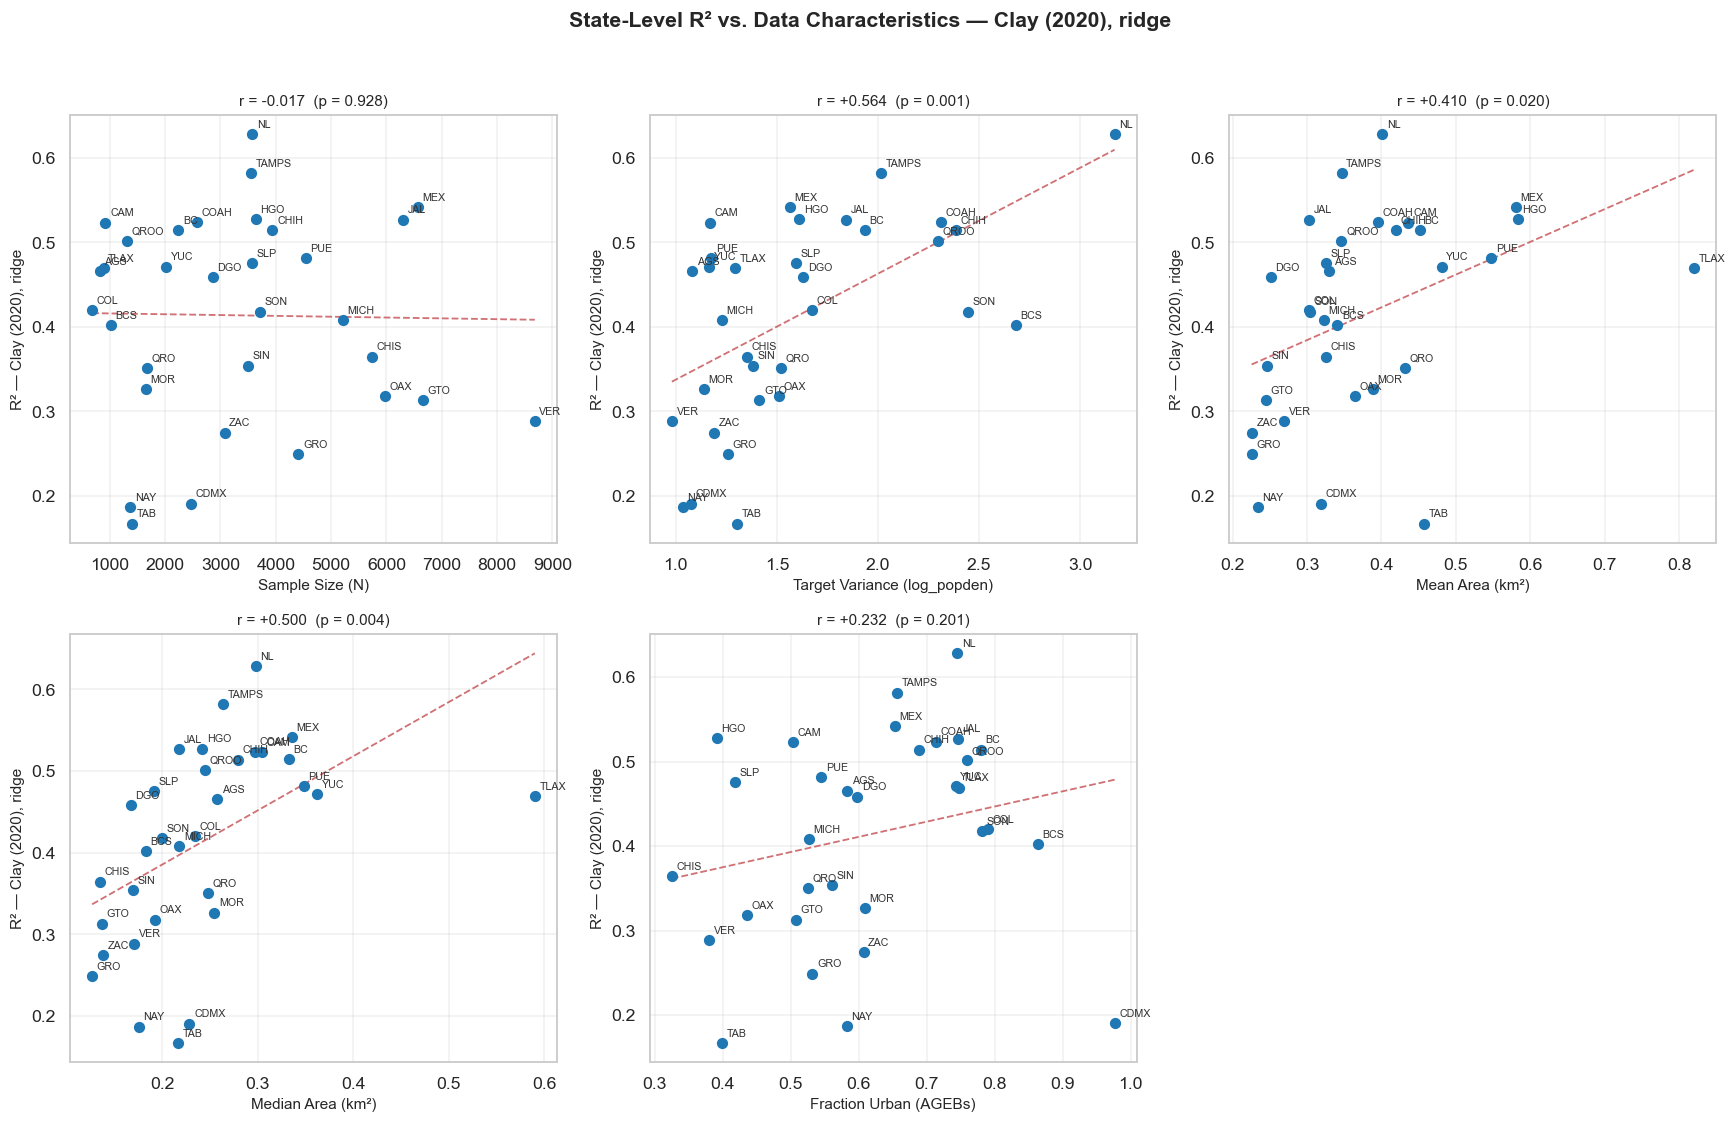

Saved: Clay (2020) / xgboost


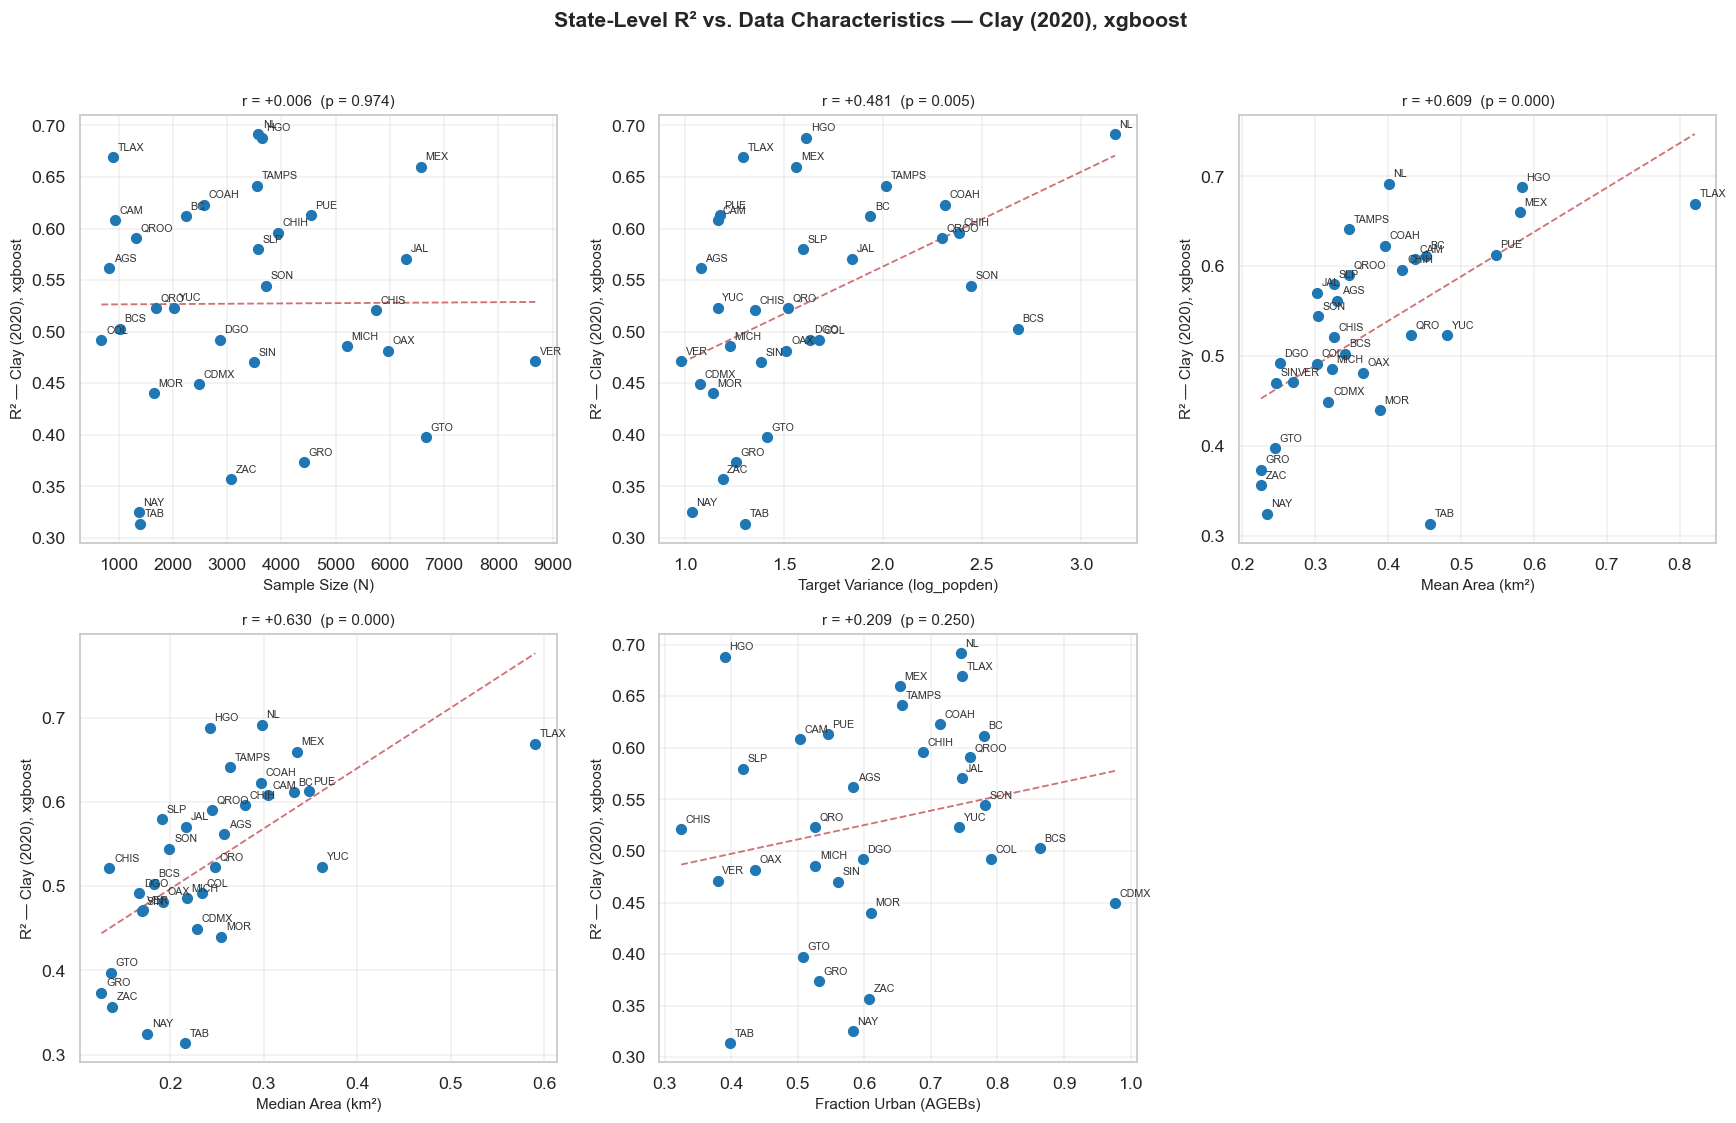

Saved: AlphaEarth (2020) / ridge


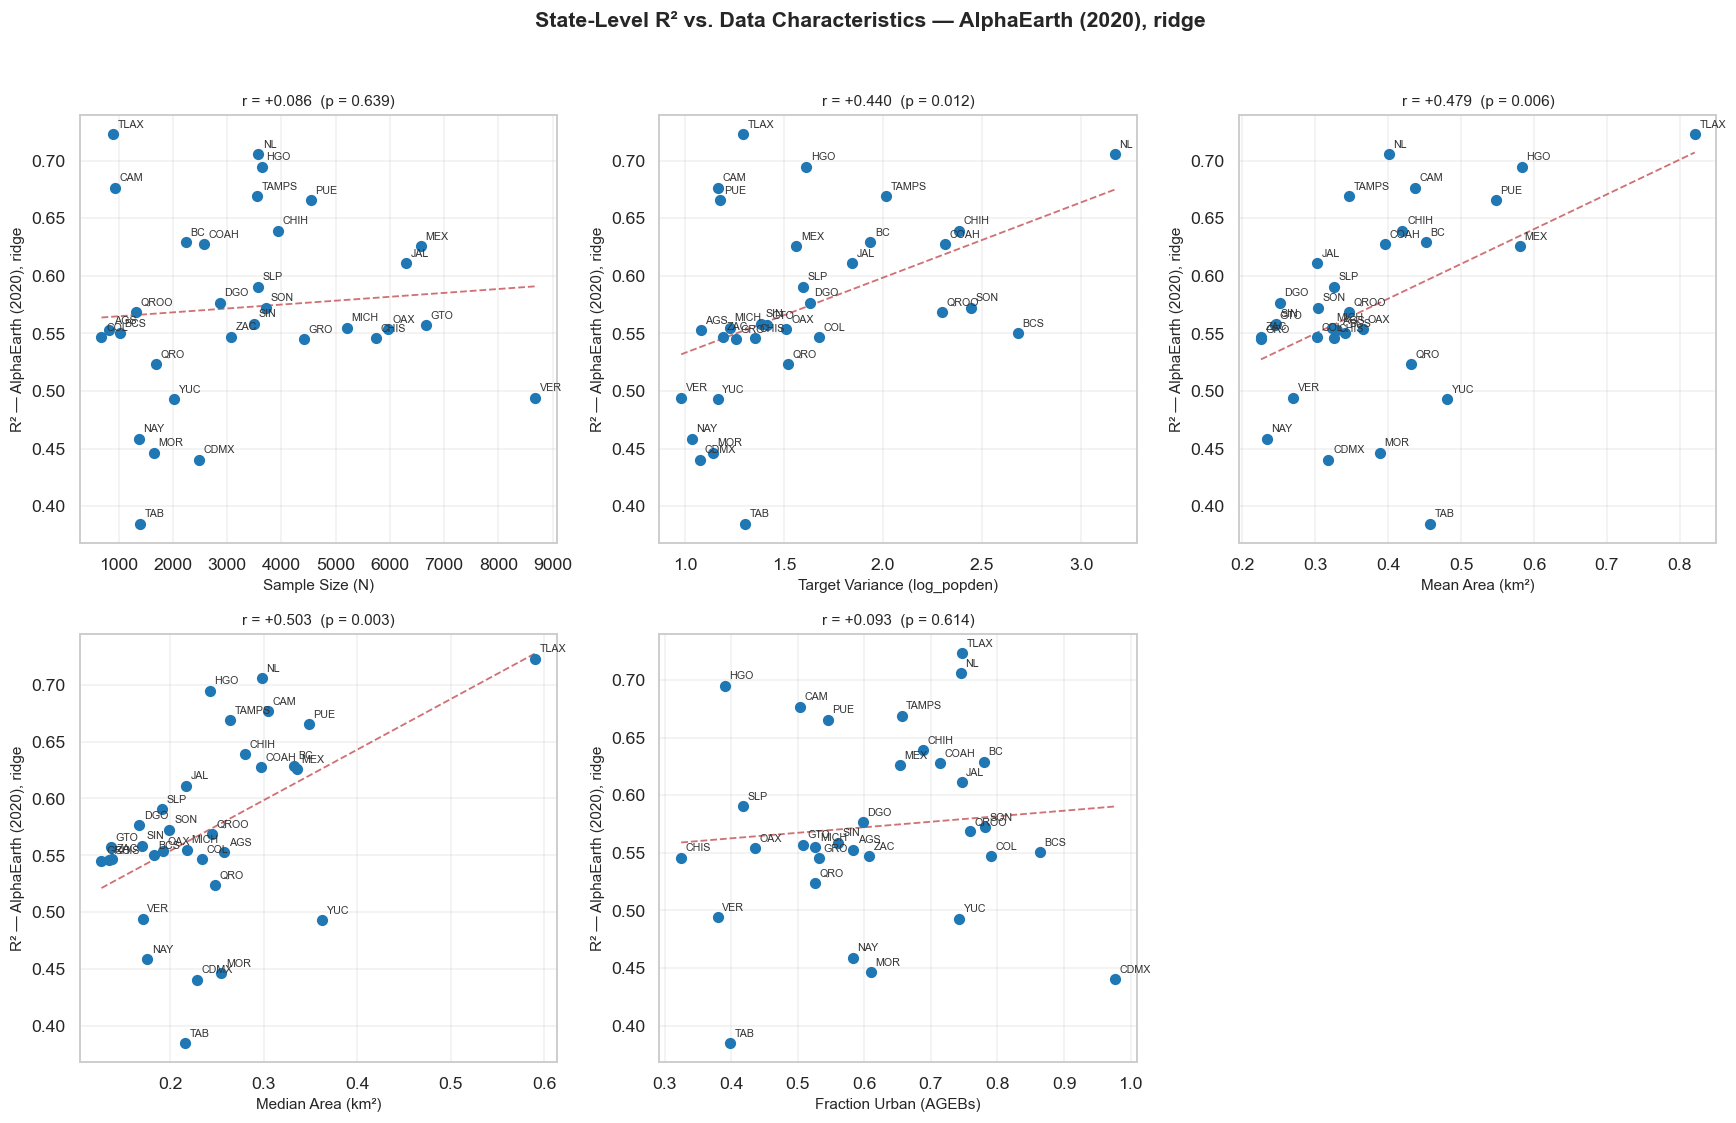

Saved: AlphaEarth (2020) / xgboost


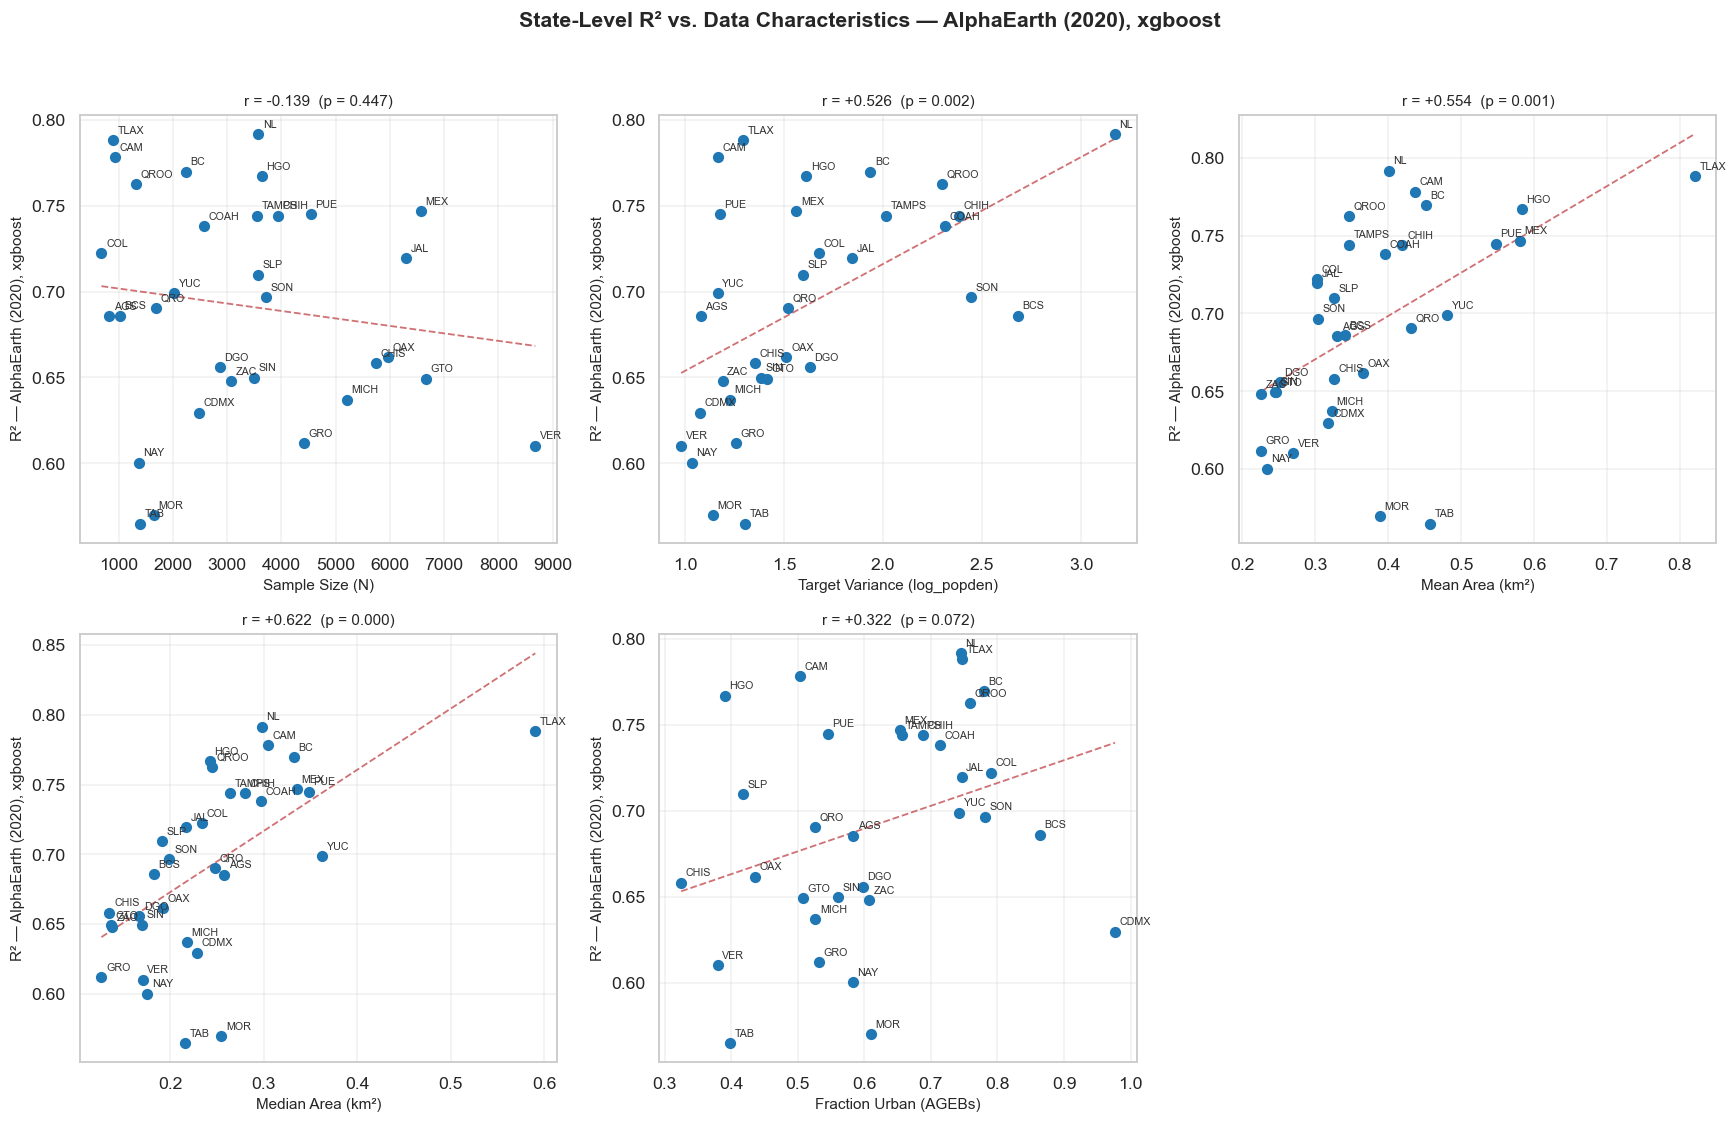

In [26]:
# --- State-Level R² vs. Data Characteristics (all embedding × model combos) ---
# Requires helpers from the state summary cell above (CVE_ENT_TO_ABBR, etc.).
from scipy import stats

_ALL_SOURCES = [
    ("Clay (2010)",      "clay2010"),
    ("Clay (2020)",      "clay2020"),
    ("AlphaEarth (2020)","alphaearth2020"),
]
_ALL_MODELS = ["ridge", "xgboost"]

# State characteristics (shared across runs) — computed once from label fold
_pred_label = _label_fold_polygon_frame(STATE_SUMMARY_LABEL_FOLD)
_lpd_var = _log_pop_density_by_state(_pred_label)
_mean_a, _med_a = _mean_median_area_km2_by_state(_pred_label)

_REPORT_FIG_DIR = RESULTS_DIR.parent / "deliverables" / "report" / "figs"
_REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

for emb_label, emb_folder in _ALL_SOURCES:
    for model_name in _ALL_MODELS:
        # Load per-state metrics for this combo
        metrics_path = RESULTS_DIR / emb_folder / "analysis_ageb" / "metrics_by_state_emb.csv"
        pred_path    = RESULTS_DIR / emb_folder / "analysis_ageb" / "predictions_oof_emb.parquet"
        if not metrics_path.is_file() or not pred_path.is_file():
            print(f"[skip] {emb_label} / {model_name}: missing artifacts")
            continue

        raw_m = pd.read_csv(metrics_path)
        sel_m = _filter_metrics_model(raw_m, model_name)
        if sel_m.empty:
            print(f"[skip] {emb_label} / {model_name}: no rows for model")
            continue

        sel_m = sel_m.copy()
        sel_m["state_abbr"] = sel_m["state"].astype(str).str.zfill(2).map(CVE_ENT_TO_ABBR)
        r2_series = sel_m.drop_duplicates("state_abbr").set_index("state_abbr")["r2"]

        # Per-state N and frac_urban from predictions
        pred = normalize_pred_frame(pd.read_parquet(pred_path))
        pred["state"] = pred["state"].astype(str).str.zfill(2)
        pred["state_abbr"] = pred["state"].map(CVE_ENT_TO_ABBR)
        pred = pred[pred["state_abbr"].notna()].copy()
        pred["_urban"] = pred["ageb_id"].astype(str).str.len().eq(13).astype(float)
        g = pred.groupby("state_abbr", sort=False)
        n_series = g.size().rename("N")
        fu_series = g["_urban"].mean().rename("frac_urban")

        # Align everything to common index
        idx = r2_series.dropna().index
        r2 = r2_series.reindex(idx)
        n_s = n_series.reindex(idx)
        fu  = fu_series.reindex(idx)
        lpd = _lpd_var.reindex(idx) if _lpd_var is not None else pd.Series(np.nan, index=idx)
        ma  = _mean_a.reindex(idx) if _mean_a is not None else pd.Series(np.nan, index=idx)
        mda = _med_a.reindex(idx) if _med_a is not None else pd.Series(np.nan, index=idx)

        chars = {}
        if n_s.notna().any():   chars["Sample Size (N)"] = n_s
        if lpd.notna().any():   chars["Target Variance (log_popden)"] = lpd
        if ma.notna().any():    chars["Mean Area (km²)"] = ma
        if mda.notna().any():   chars["Median Area (km²)"] = mda
        if fu.notna().any():    chars["Fraction Urban (AGEBs)"] = fu

        if not chars:
            print(f"[skip] {emb_label} / {model_name}: no characteristics available")
            continue

        n_chars = len(chars)
        ncols = 3
        nrows = (n_chars + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
        axes = np.array(axes).flatten()

        _ylabel = f"R² — {emb_label}, {model_name}"

        for i, (cname, cvals) in enumerate(chars.items()):
            ax = axes[i]
            mask = cvals.notna() & r2.notna()
            x = cvals[mask].values.astype(float)
            y = r2[mask].values.astype(float)
            labs = mask[mask].index.values

            ax.scatter(x, y, color="#1f77b4", s=40, zorder=3)
            for xi, yi, lab in zip(x, y, labs):
                ax.annotate(lab, (xi, yi), fontsize=7, ha="left", va="bottom",
                            xytext=(3, 3), textcoords="offset points", color="#333")

            if len(x) > 2:
                r_val, p_val = stats.pearsonr(x, y)
                slope, intercept = np.polyfit(x, y, 1)
                xl = np.linspace(x.min(), x.max(), 100)
                ax.plot(xl, slope * xl + intercept, "r--", lw=1.2, alpha=0.8)
                sign = "+" if r_val >= 0 else ""
                ax.set_title(f"r = {sign}{r_val:.3f}  (p = {p_val:.3f})", fontsize=10)

            ax.set_xlabel(cname, fontsize=10)
            ax.set_ylabel(_ylabel, fontsize=10)
            ax.grid(True, alpha=0.3)

        for i in range(n_chars, len(axes)):
            axes[i].set_visible(False)

        fig.suptitle(
            f"State-Level R² vs. Data Characteristics — {emb_label}, {model_name}",
            fontsize=14, fontweight="bold", y=1.02,
        )
        plt.tight_layout()

        _slug = f"{emb_folder}_{model_name}"
        for ext in ("pdf", "png"):
            fig.savefig(
                _REPORT_FIG_DIR / f"state_r2_vs_characteristics_{_slug}.{ext}",
                bbox_inches="tight", dpi=200,
            )
        print(f"Saved: {emb_label} / {model_name}")
        plt.show()


## Table Version of the State-Level R^2 vs. Data Characteristics Plots`

In [40]:
import pandas as pd
from scipy import stats

# --- Summary Table: R² vs. Data Characteristics ---
all_summary_rows = []

for emb_label, emb_folder in _ALL_SOURCES:
    for model_name in _ALL_MODELS:
        # 1. Load metrics and predictions (reuse existing paths)
        metrics_path = RESULTS_DIR / emb_folder / "analysis_ageb" / "metrics_by_state_emb.csv"
        pred_path    = RESULTS_DIR / emb_folder / "analysis_ageb" / "predictions_oof_emb.parquet"
        
        if not metrics_path.is_file() or not pred_path.is_file():
            continue

        # 2. Extract State R2
        raw_m = pd.read_csv(metrics_path)
        sel_m = _filter_metrics_model(raw_m, model_name)
        if sel_m.empty: continue
        
        sel_m = sel_m.copy()
        sel_m["state_abbr"] = sel_m["state"].astype(str).str.zfill(2).map(CVE_ENT_TO_ABBR)
        r2_series = sel_m.drop_duplicates("state_abbr").set_index("state_abbr")["r2"]

        # 3. Compute characteristics (Sample Size & Urban Fraction)
        pred = normalize_pred_frame(pd.read_parquet(pred_path))
        pred["state_abbr"] = pred["state"].astype(str).str.zfill(2).map(CVE_ENT_TO_ABBR)
        pred["_urban"] = pred["ageb_id"].astype(str).str.len().eq(13).astype(float)
        
        g = pred.groupby("state_abbr")
        n_series = g.size()
        fu_series = g["_urban"].mean()

        # 4. Align with shared characteristics (_lpd_var, _mean_a, etc.)
        idx = r2_series.dropna().index
        target_r2 = r2_series.reindex(idx)
        
        current_chars = {
            "Sample Size (N)": n_series.reindex(idx),
            "Target Variance": _lpd_var.reindex(idx),
            "Mean Area (km²)": _mean_a.reindex(idx),
            "Median Area (km²)": _med_a.reindex(idx),
            "Fraction Urban": fu_series.reindex(idx)
        }

        # 5. Calculate Correlations for each characteristic
        for cname, cvals in current_chars.items():
            mask = cvals.notna() & target_r2.notna()
            x = cvals[mask].values.astype(float)
            y = target_r2[mask].values.astype(float)
            
            if len(x) > 2:
                r_val, p_val = stats.pearsonr(x, y)
                
                all_summary_rows.append({
                    "Embedding Source": emb_label,
                    "Model Head": model_name.upper(),
                    "Characteristic": cname,
                    "Pearson r": round(r_val, 4),
                    "p-value": round(p_val, 4),
                    "Significant (0.05)": p_val < 0.05,
                    "Avg State R²": round(target_r2.mean(), 3),
                    "Num States": len(x)
                })

# Create and format DataFrame
df_summary = pd.DataFrame(all_summary_rows)

# Apply some styling for easier reading in the notebook
display(df_summary.sort_values(["Characteristic", "Pearson r"], ascending=[True, False])
        .style.background_gradient(subset=['Pearson r'], cmap='RdYlGn', vmin=-1, vmax=1)
        .set_caption("Summary of Correlations between State Performance (R²) and Data Characteristics"))

# --- Aggregated Summary: Which characteristics matter most? ---
# Assuming 'df_summary' is the dataframe from the previous cell

agg_summary = df_summary.groupby("Characteristic").agg({
    "Pearson r": ["mean", "std"],
    "Significant (0.05)": "sum"
})

# Flatten columns (Removed "Total Tests")
agg_summary.columns = ["Avg Pearson r", "r Std Dev", "Times Significant"]

# Calculate Significance Rate
# Note: Ensure _ALL_SOURCES and _ALL_MODELS are defined in your environment
agg_summary["Significance Rate (%)"] = (agg_summary["Times Significant"] / (len(_ALL_SOURCES) * len(_ALL_MODELS))) * 100

# Sort by the most impactful characteristics
agg_summary = agg_summary.sort_values("Avg Pearson r", ascending=False)

display(agg_summary.style.background_gradient(subset=["Avg Pearson r"], cmap="RdYlGn")
        .format("{:.3f}", subset=["Avg Pearson r", "r Std Dev"])
        .format("{:.1f}%", subset=["Significance Rate (%)"]))



# 1. Calculate the 'rank' based on Avg Pearson r so the most important characteristics stay at the top
char_rank = df_summary.groupby("Characteristic")["Pearson r"].mean().sort_values(ascending=False).index

# 2. Reorder and set up the nested index
df_detailed = df_summary.copy()
df_detailed["Characteristic"] = pd.Categorical(df_detailed["Characteristic"], categories=char_rank, ordered=True)
df_detailed = df_detailed.sort_values(["Characteristic", "Pearson r"], ascending=[True, False])

# 3. Create the multi-index for a clean "nested" look
df_final = df_detailed.set_index(["Characteristic", "Embedding Source", "Model Head"])

# 4. Final display with styling
display(df_final.style
    .background_gradient(subset=['Pearson r'], cmap='RdYlGn', vmin=-1, vmax=1)
    .applymap(lambda v: 'font-weight: bold; color: #d62728' if v > 0.05 else 'color: #2ca02c', subset=['p-value'])
    .format("{:.4f}", subset=["Pearson r", "p-value", "Avg State R²"])
    .set_caption("Detailed Pearson Correlations: Grouped by Data Characteristic")
)
# Optional: Save to CSV
# df_summary.to_csv(_REPORT_FIG_DIR / "state_r2_correlation_summary.csv", index=False)

/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/4196657021.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, p_val = stats.pearsonr(x, y)
/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/4196657021.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, p_val = stats.pearsonr(x, y)


,Embedding Source,Model Head,Characteristic,Pearson r,p-value,Significant (0.05),Avg State R²,Num States
29,AlphaEarth (2020),XGBOOST,Fraction Urban,0.321900,0.072400,False,0.692000,32
14,Clay (2020),RIDGE,Fraction Urban,0.232000,0.201400,False,0.414000,32
19,Clay (2020),XGBOOST,Fraction Urban,0.209500,0.249900,False,0.527000,32
24,AlphaEarth (2020),RIDGE,Fraction Urban,0.092700,0.614000,False,0.573000,32
4,Clay (2010),RIDGE,Fraction Urban,nan,nan,False,0.493000,32
9,Clay (2010),XGBOOST,Fraction Urban,nan,nan,False,0.557000,32
7,Clay (2010),XGBOOST,Mean Area (km²),0.614200,0.000200,True,0.557000,32
17,Clay (2020),XGBOOST,Mean Area (km²),0.608900,0.000200,True,0.527000,32
2,Clay (2010),RIDGE,Mean Area (km²),0.555600,0.001000,True,0.493000,32
27,AlphaEarth (2020),XGBOOST,Mean Area (km²),0.553700,0.001000,True,0.692000,32


,Avg Pearson r,r Std Dev,Times Significant,Significance Rate (%)
Characteristic,,,,
Median Area (km²),0.560,0.065,6,100.0%
Mean Area (km²),0.537,0.079,6,100.0%
Target Variance,0.355,0.232,4,66.7%
Fraction Urban,0.214,0.094,0,0.0%
Sample Size (N),0.056,0.134,0,0.0%


/var/folders/wj/jb77bj_s2cq6q3yjqtnb8wr40000gn/T/ipykernel_12141/4196657021.py:112: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'font-weight: bold; color: #d62728' if v > 0.05 else 'color: #2ca02c', subset=['p-value'])


## Temporal Cross-analysis (Clay 2010 vs 2020)

Summarizes cross-temporal experiments from `clay2020/cross_temporal/`:
- `baseline_2010_2020_cv`: 2010 embeddings predicting 2020 targets.
- `baseline_delta_2020_cv`: 2010 and delta embeddings predicting 2020 targets.
- `transfer_2010_to_2020`: Zero-shot transfer from 2010 models to 2020.

Includes change-detection hexbins comparing predicted vs actual log-density deltas.

,Specification,Ridge $R^2$,Ridge MAE,XGB $R^2$,XGB MAE,$n$,Meta
0,"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",0.5533,0.5741,0.6084,0.5277,"52,086",baseline_2010_2020_cv; emb2010; random 5-fold (seed=0)
1,"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \to$ 2020 (matched AGEBs, 5-fold OOF)",0.6121,0.5299,0.6389,0.5036,"52,086",baseline_delta_2020_cv; emb2010_plus_delta; random 5-fold (seed=0)
2,Train all 2010 $\to$ predict 2020 (full 2020 grid; no OOF),0.3668,0.7255,0.4555,0.6617,"106,564","transfer_2010_to_2020; train=2010, test=2020"


,Specification,Meta
0,"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",baseline_2010_2020_cv; emb2010; random 5-fold ...
1,"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \...",baseline_delta_2020_cv; emb2010_plus_delta; ra...
2,Train all 2010 $\to$ predict 2020 (full 2020 g...,"transfer_2010_to_2020; train=2010, test=2020"



Per-state CSV artifacts (``metrics_by_state_*.csv``):
  metrics_by_state_baseline_2010_2020_cv.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
  metrics_by_state_baseline_delta_2020_cv.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
  metrics_by_state_transfer_2010_to_2020.csv: 64 rows, columns ['model', 'state', 'r2', 'mae', 'rmse', 'n']...
[temporal] matched AGEB panel for $\Delta$ plots: 52,086 rows
Saved: /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/temporal_change_hexbin_cross_temporal.pdf | /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs/temporal_change_hexbin_cross_temporal.png


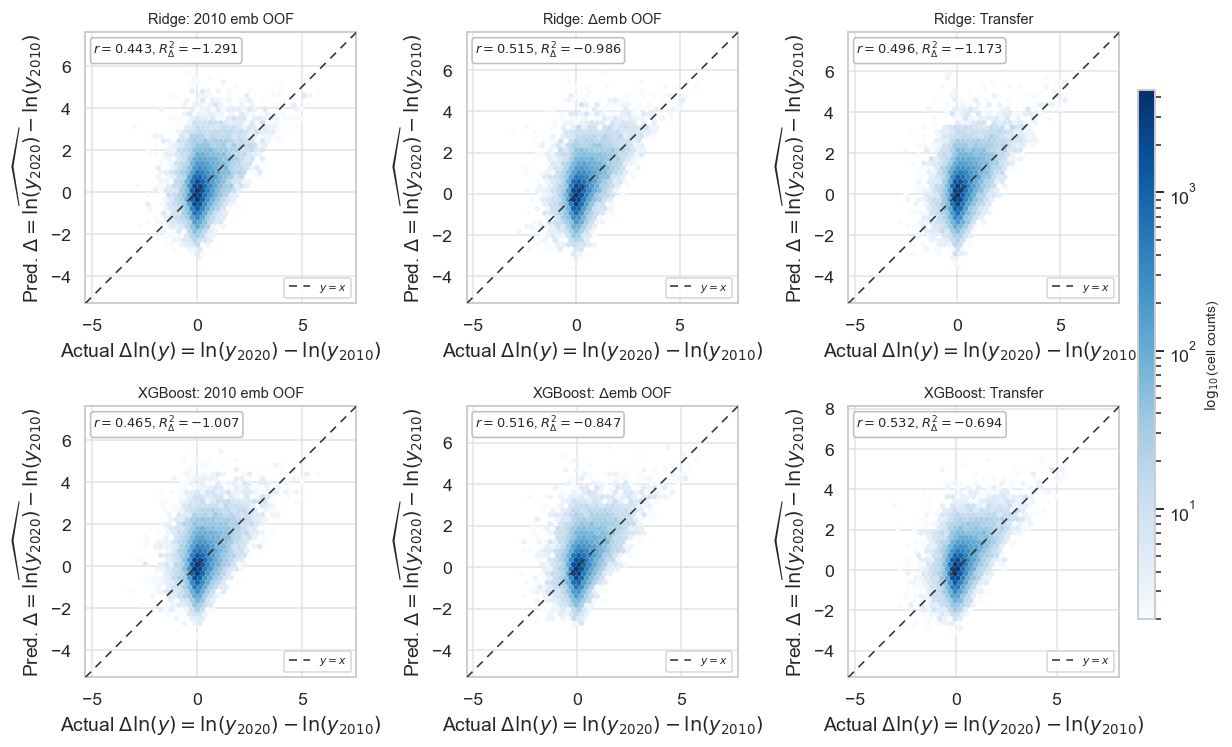

$R^2_\Delta$: sklearn with actual $\Delta$ as truth; can be $<0$ while $r>0$. Saved ``temporal_change_hexbin_cross_temporal`` under /Users/henrychen/Desktop/CS-Econ Thesis/deliverables/report/figs.


In [41]:
# --- clay2020/cross_temporal: three JSON metrics + Δ hexbins (three parquets) ---
# Uses ``normalize_pred_frame`` from above (optional elsewhere) and ``_save_report_fig`` from the calibration cell.

from sklearn.metrics import r2_score

TEMP_CHANGE_MAX_POINTS = 45_000
TEMP_CHANGE_RNG = np.random.default_rng(43)

CROSS_TEMPORAL = RESULTS_DIR / "clay2020" / "cross_temporal"
_path_oof2010 = RESULTS_DIR / "clay2010" / "analysis_ageb" / "predictions_oof_emb.parquet"

CROSS_TEMPORAL_JSON_ROWS: list[tuple[str, str]] = [
    (
        r"2010 emb $\to$ 2020 (matched AGEBs, 5-fold OOF)",
        "metrics_overall_baseline_2010_2020_cv.json",
    ),
    (
        r"$[\mathrm{emb}_{2010},\, \Delta\mathrm{emb}] \to$ 2020 (matched AGEBs, 5-fold OOF)",
        "metrics_overall_baseline_delta_2020_cv.json",
    ),
    (
        r"Train all 2010 $\to$ predict 2020 (full 2020 grid; no OOF)",
        "metrics_overall_transfer_2010_to_2020.json",
    ),
]

PATH_PRED_MATCHED: dict[str, Path] = {
    "baseline": CROSS_TEMPORAL / "predictions_baseline_2010_2020_cv.parquet",
    "delta": CROSS_TEMPORAL / "predictions_baseline_delta_2020_cv.parquet",
    "transfer": CROSS_TEMPORAL / "predictions_transfer_2010_to_2020.parquet",
}


def _json_metrics_row(spec_label: str, path: Path) -> dict | None:
    if not path.is_file():
        print(f"[temporal] missing metrics JSON: {path.relative_to(RESULTS_DIR)}")
        return None
    j = json.loads(path.read_text())
    ridge = j["metrics"]["ridge"]
    xgb = j["metrics"]["xgboost"]
    bits: list[str] = []
    if j.get("experiment"):
        bits.append(str(j["experiment"]))
    if j.get("feature_set"):
        bits.append(str(j["feature_set"]))
    if j.get("cv"):
        bits.append(str(j["cv"]))
    if j.get("train_year") is not None and j.get("test_year") is not None:
        bits.append(f"train={j['train_year']}, test={j['test_year']}")
    return {
        "Specification": spec_label,
        r"Ridge $R^2$": ridge["r2"],
        "Ridge MAE": ridge["mae"],
        r"XGB $R^2$": xgb["r2"],
        "XGB MAE": xgb["mae"],
        "$n$": int(ridge["n"]),
        "Meta": "; ".join(bits),
    }


_rows = []
for lab, fn in CROSS_TEMPORAL_JSON_ROWS:
    row = _json_metrics_row(lab, CROSS_TEMPORAL / fn)
    if row:
        _rows.append(row)

if _rows:
    cross_year_metrics = pd.DataFrame(_rows)
    num_cols = [c for c in cross_year_metrics.columns if c != "Specification"]
    fmt = {c: "{:.4f}" for c in num_cols if c not in ("$n$", "Meta")}
    fmt["$n$"] = "{:,.0f}"
    display(
        cross_year_metrics.style.format(fmt, subset=[c for c in num_cols if c != "Meta"], na_rep="—").set_caption(
            "Clay ``cross_temporal``: rows from ``metrics_overall_*.json``. Meta column documents experiment tags from JSON."
        )
    )
    display(cross_year_metrics[["Specification", "Meta"]])
else:
    cross_year_metrics = pd.DataFrame()
    print("[temporal] No metrics rows assembled (missing cross_temporal JSON artifacts).")

print("\nPer-state CSV artifacts (``metrics_by_state_*.csv``):")
for stem in (
    "baseline_2010_2020_cv",
    "baseline_delta_2020_cv",
    "transfer_2010_to_2020",
):
    p_csv = CROSS_TEMPORAL / f"metrics_by_state_{stem}.csv"
    if p_csv.is_file():
        z = pd.read_csv(p_csv)
        print(f"  {p_csv.name}: {len(z)} rows, columns {list(z.columns)[:6]}...")
    else:
        print(f"  [missing] {p_csv.name}")


def _pred_parquet_xgb_col(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def _hex_change_panel(ax, x_act: np.ndarray, y_pred: np.ndarray, *, title: str, xlab: str, ylab: str):
    m = np.isfinite(x_act) & np.isfinite(y_pred)
    xa, yp = x_act[m], y_pred[m]
    lo = float(min(xa.min(), yp.min()))
    hi = float(max(xa.max(), yp.max()))
    pad = 0.03 * (hi - lo) if hi > lo else 0.05
    lo, hi = lo - pad, hi + pad
    hb = ax.hexbin(
        xa,
        yp,
        gridsize=52,
        mincnt=2,
        extent=(lo, hi, lo, hi),
        cmap="Blues",
        linewidths=0.0,
        bins="log",
    )
    ax.plot([lo, hi], [lo, hi], color="0.2", ls=(0, (5, 4)), lw=1.05, zorder=6, label=r"$y = x$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, color="0.88", zorder=0, alpha=0.85)
    ax.legend(loc="lower right", fontsize=7)
    r_pearson = float(np.corrcoef(xa, yp)[0, 1]) if len(xa) > 1 else float("nan")
    r2_chg = float(r2_score(xa, yp))
    ax.text(
        0.03,
        0.97,
        rf"$r={r_pearson:.3f}$, $R^2_\Delta={r2_chg:.3f}$",
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="0.72", alpha=0.92),
        zorder=10,
    )
    return hb


missing_pred = [str(p.relative_to(RESULTS_DIR)) for p in PATH_PRED_MATCHED.values() if not p.is_file()]
if missing_pred:
    print(f"[temporal] Missing prediction parquet(s): {missing_pred}")
elif not _path_oof2010.is_file():
    print("[temporal] Missing clay2010 OOF parquet for $\\ln(y_{2010})$.")
else:
    base = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["baseline"]))
    delta = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["delta"]))
    xfer = _pred_parquet_xgb_col(pd.read_parquet(PATH_PRED_MATCHED["transfer"]))

    panel = base[["ageb_id", "state", "y"]].rename(columns={"y": "y_ln_2020"})
    panel = panel.merge(
        base[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_base", "pred_xgb": "pred_xgb_base"}
        ),
        on="ageb_id",
        how="inner",
    )
    panel = panel.merge(
        delta[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_delta", "pred_xgb": "pred_xgb_delta"}
        ),
        on="ageb_id",
        how="inner",
    )
    panel = panel.merge(
        xfer[["ageb_id", "pred_ridge", "pred_xgb"]].rename(
            columns={"pred_ridge": "pred_ridge_xfer", "pred_xgb": "pred_xgb_xfer"}
        ),
        on="ageb_id",
        how="inner",
    )
    y2010 = pd.read_parquet(_path_oof2010, columns=["ageb_id", "y"]).rename(columns={"y": "y_ln_2010"})
    panel = panel.merge(y2010, on="ageb_id", how="inner")
    print(f"[temporal] matched AGEB panel for $\\Delta$ plots: {len(panel):,} rows")

    d_act = panel["y_ln_2020"].to_numpy(dtype=float) - panel["y_ln_2010"].to_numpy(dtype=float)

    heads = [
        ("Ridge", ["pred_ridge_base", "pred_ridge_delta", "pred_ridge_xfer"]),
        ("XGBoost", ["pred_xgb_base", "pred_xgb_delta", "pred_xgb_xfer"]),
    ]
    tags = ["2010 emb OOF", r"$\Delta$emb OOF", "Transfer"]

    fig, axes = plt.subplots(2, 3, figsize=(12.2, 7.15))
    plt.subplots_adjust(left=0.055, right=0.99, top=0.9, bottom=0.08, wspace=0.34, hspace=0.38)
    mappable = None
    idx = np.arange(len(panel))
    if len(idx) > TEMP_CHANGE_MAX_POINTS:
        idx = TEMP_CHANGE_RNG.choice(len(panel), TEMP_CHANGE_MAX_POINTS, replace=False)
    xa = d_act[idx]
    xlab = r"Actual $\Delta\ln(y)=\ln(y_{2020})-\ln(y_{2010})$"
    ylab = r"Pred. $\Delta=\widehat{\ln(y_{2020})}-\ln(y_{2010})$"

    y10 = panel["y_ln_2010"].to_numpy(dtype=float)
    for i, (hname, pred_cols) in enumerate(heads):
        for j, pc in enumerate(pred_cols):
            dp = panel[pc].to_numpy(dtype=float) - y10
            yp = dp[idx]
            hb = _hex_change_panel(
                axes[i, j],
                xa,
                yp,
                title=f"{hname}: {tags[j]}",
                xlab=xlab,
                ylab=ylab,
            )
            mappable = hb

    cbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015, aspect=32)
    cbar.set_label(r"$\log_{10}$(cell counts)", fontsize=9)
    # fig.suptitle(
    #     r"Clay matched AGEBs: $\Delta\ln(y)$ actual vs.\ predicted — three ``cross_temporal`` parquets",
    #     fontsize=11.5,
    #     y=0.98,
    # )
    _save_report_fig(fig, "temporal_change_hexbin_cross_temporal")
    plt.show()

    print(
        "$R^2_\\Delta$: sklearn with actual $\\Delta$ as truth; can be $<0$ while $r>0$. "
        f"Saved ``temporal_change_hexbin_cross_temporal`` under {CAL_RES_FIG_DIR.resolve()}."
    )


## Out-of-fold $R^2$ Summary Table

Generates a summary table of $R^2$ scores across embedding sources, models, and spatial scales (log and linear targets). Uses `predictions_oof_emb.parquet`.

In [19]:
import numpy as np
from sklearn.metrics import r2_score

# Row order matches thesis table
TABLE8_SOURCES: list[tuple[str, str]] = [
    ("AlphaEarth (2020 labels)", "alphaearth2020"),
    ("Clay (2020 labels)", "clay2020"),
    ("Clay (2010 labels)", "clay2010"),
]

COLS_TABLE8 = pd.MultiIndex.from_tuples(
    [
        ("Polygon level (AGEB and localities)", r"$R^2_{\ln}$"),
        ("Polygon level (AGEB and localities)", r"$R^2_{\mathrm{orig}}$"),
        ("Municipality level", r"$R^2_{\ln}$"),
        ("Municipality level", r"$R^2_{\mathrm{orig}}$"),
    ],
    names=["Spatial scale", "Metric"],
)


def _norm_pred_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "pred_xgboost" in out.columns and "pred_xgb" not in out.columns:
        out["pred_xgb"] = out["pred_xgboost"]
    return out


def _r2_ln(y: np.ndarray, p: np.ndarray) -> float:
    return float(r2_score(y, p))


def _r2_orig(y_log: np.ndarray, p_log: np.ndarray) -> float:
    """Naive density-scale R²: exp(log density), no smearing / bias correction."""
    return float(r2_score(np.exp(y_log), np.exp(p_log)))


def _load_oof_table8(folder: str, analysis: str) -> pd.DataFrame | None:
    p = RESULTS_DIR / folder / analysis / "predictions_oof_emb.parquet"
    if not p.is_file():
        return None
    return _norm_pred_cols(pd.read_parquet(p))


def build_table8() -> pd.DataFrame:
    rows_idx: list[tuple[str, str]] = []
    rows_data: list[list[float]] = []

    for emb_label, folder in TABLE8_SOURCES:
        poly = _load_oof_table8(folder, "analysis_ageb")
        muni = _load_oof_table8(folder, "analysis_muni_rollup")
        for head, pred_col in [("Ridge", "pred_ridge"), ("XGBoost", "pred_xgb")]:
            rows_idx.append((emb_label, head))
            chunk: list[float] = []
            for d in (poly, muni):
                if d is None or pred_col not in d.columns:
                    chunk.extend([np.nan, np.nan])
                else:
                    y = d["y"].to_numpy(dtype=float)
                    pr = d[pred_col].to_numpy(dtype=float)
                    chunk.append(_r2_ln(y, pr))
                    chunk.append(_r2_orig(y, pr))
            rows_data.append(chunk)

    idx = pd.MultiIndex.from_tuples(rows_idx, names=["Embedding setup", "Head"])
    return pd.DataFrame(rows_data, index=idx, columns=COLS_TABLE8)


table8 = build_table8()
display(
    table8.style.format("{:.3f}", na_rep="—").set_caption(
        "Table 8 (placeholder caption). Out-of-fold regression metrics by embedding source and census year."
    )
)

print(
    "\nNotes: (1) $R^2_{\\ln}$ is sklearn $R^2$ on the log-density target. "
    "(2) $R^2_{\\mathrm{orig}}$ uses the same naive back-transform $\\exp(\\cdot)$ on "
    "$y$ and on predictions (document if you later add bias correction / smearing). "
    "(3) RMSE / MAE rows can be added in the same pattern when results are final."
)


Notes: (1) $R^2_{\ln}$ is sklearn $R^2$ on the log-density target. (2) $R^2_{\mathrm{orig}}$ uses the same naive back-transform $\exp(\cdot)$ on $y$ and on predictions (document if you later add bias correction / smearing). (3) RMSE / MAE rows can be added in the same pattern when results are final.



--- OOF prediction parquets ---


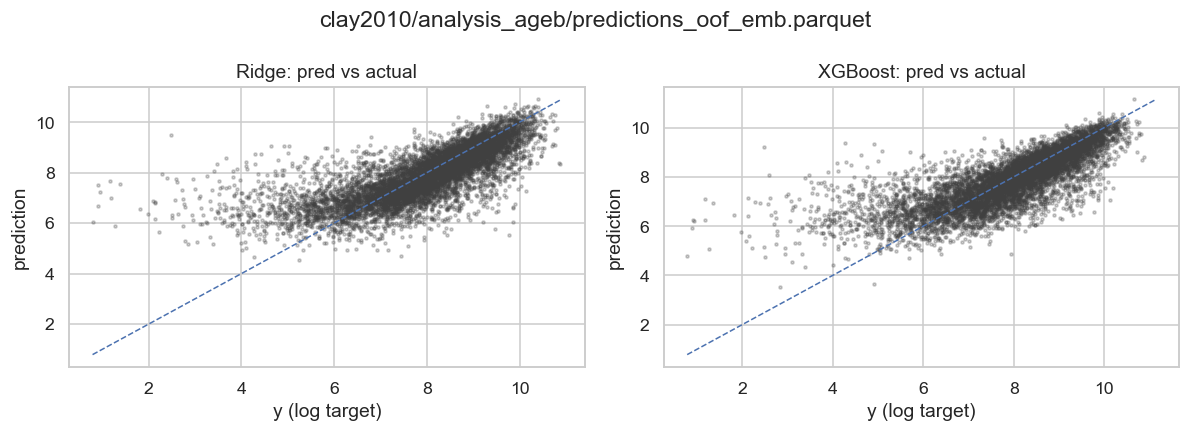

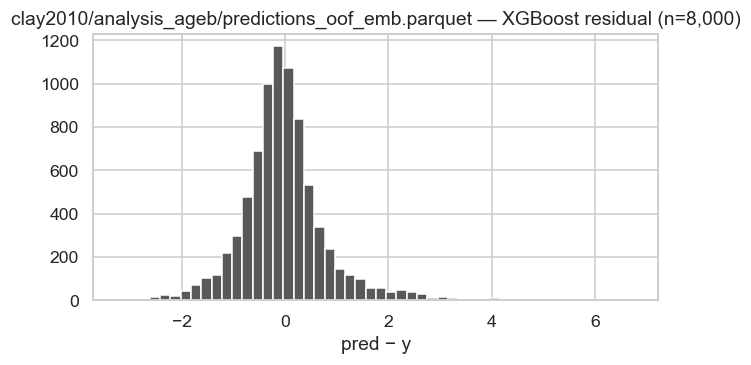

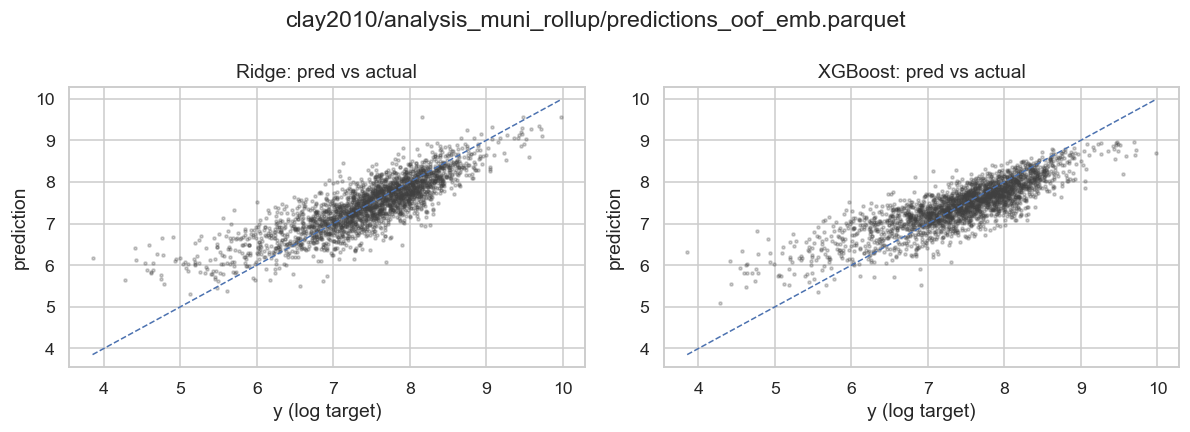

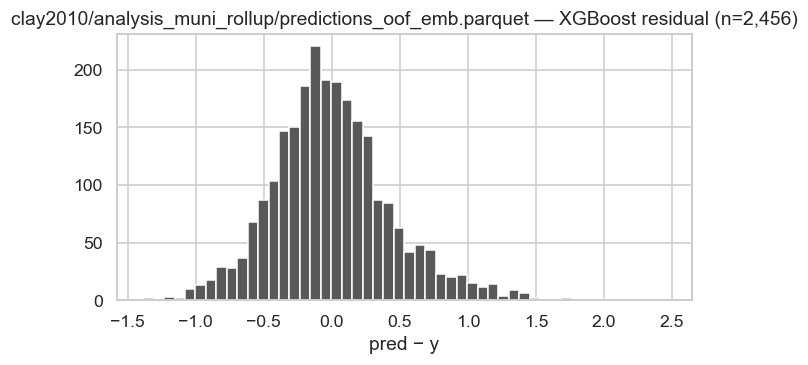

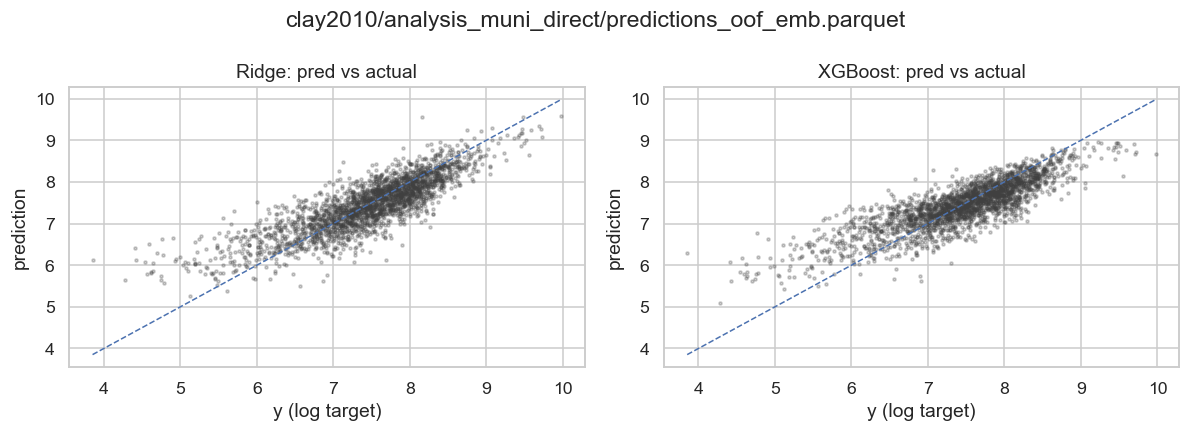

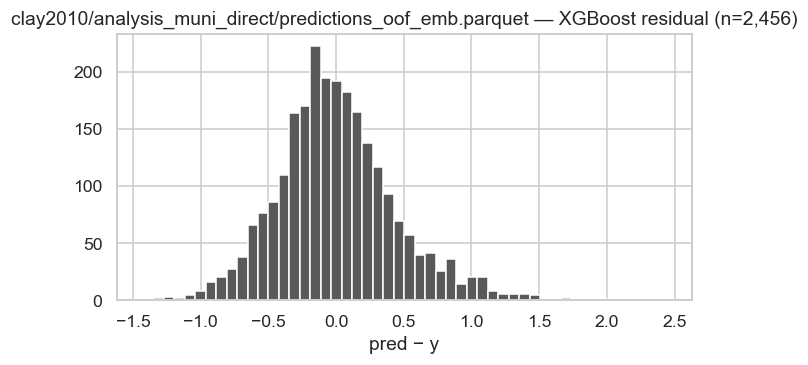

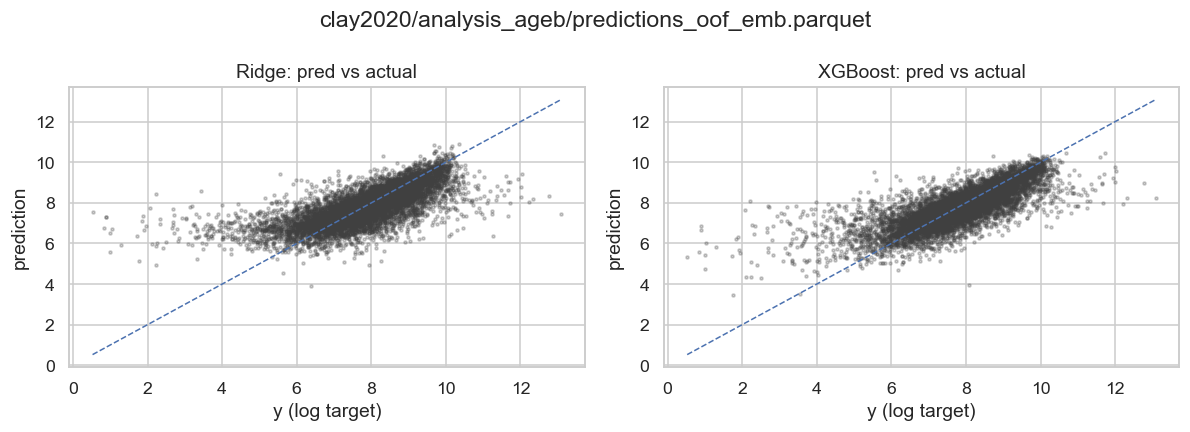

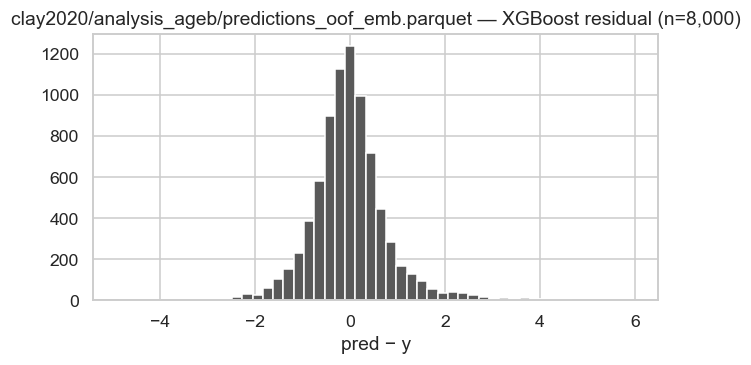

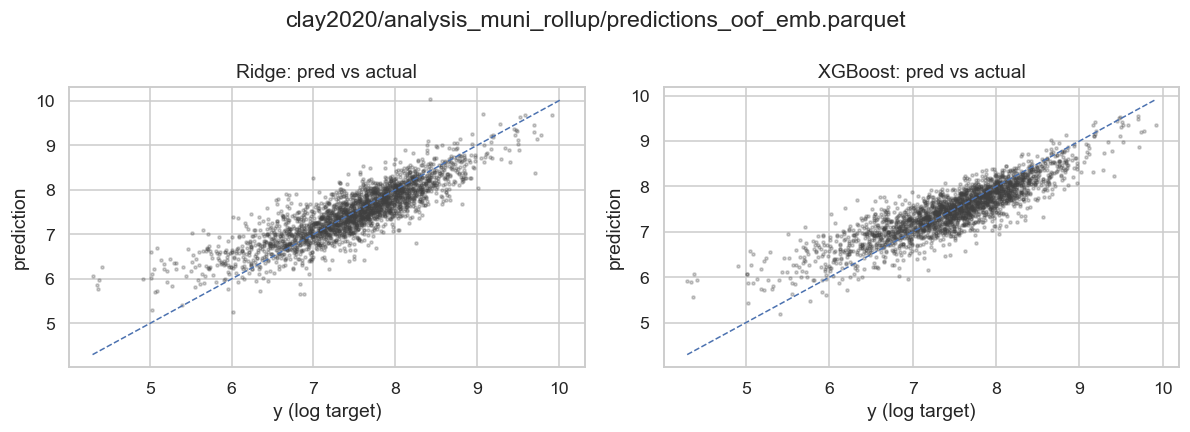

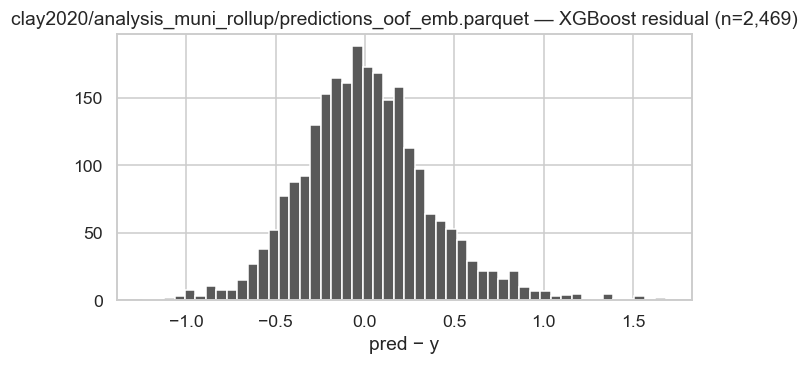

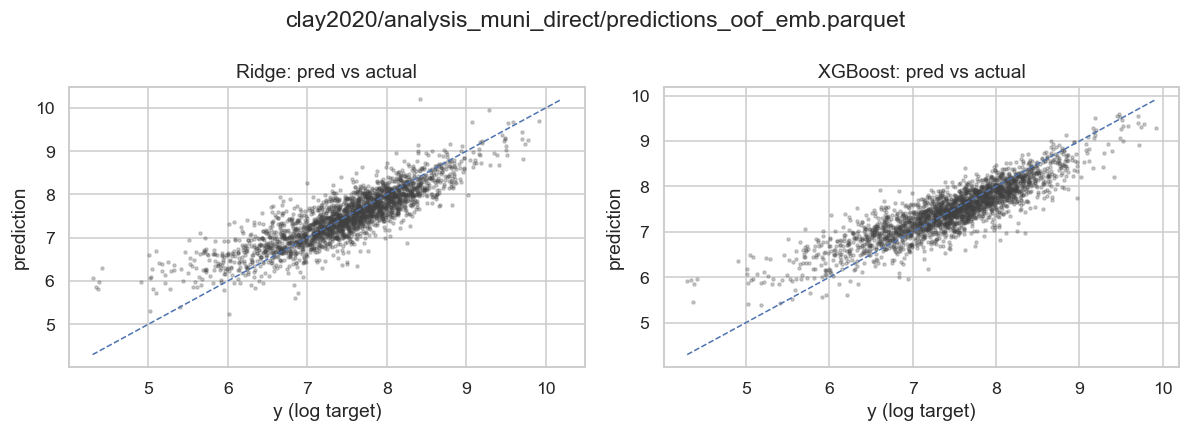

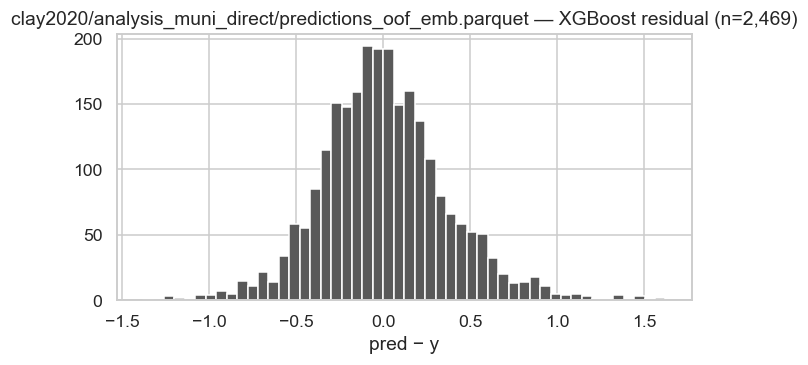

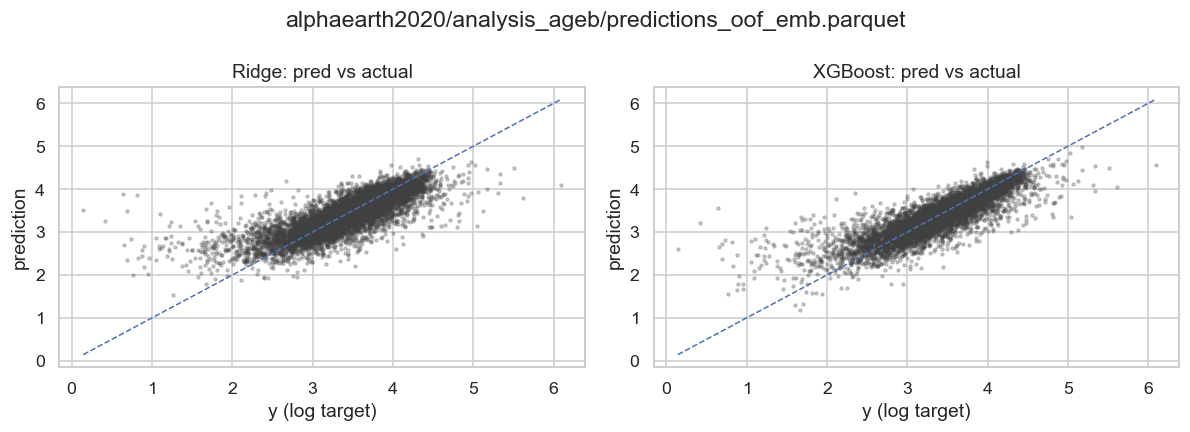

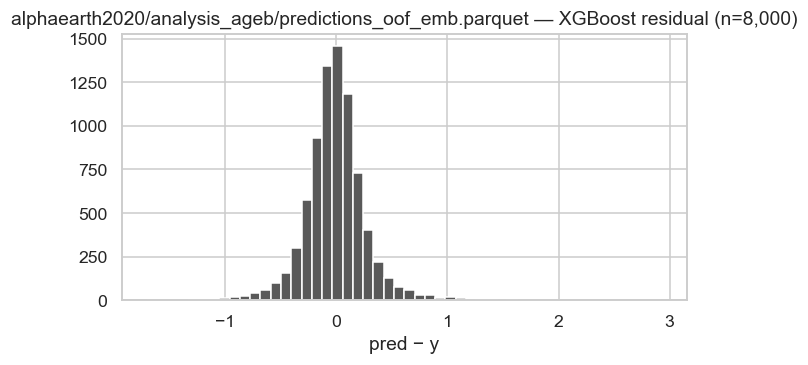

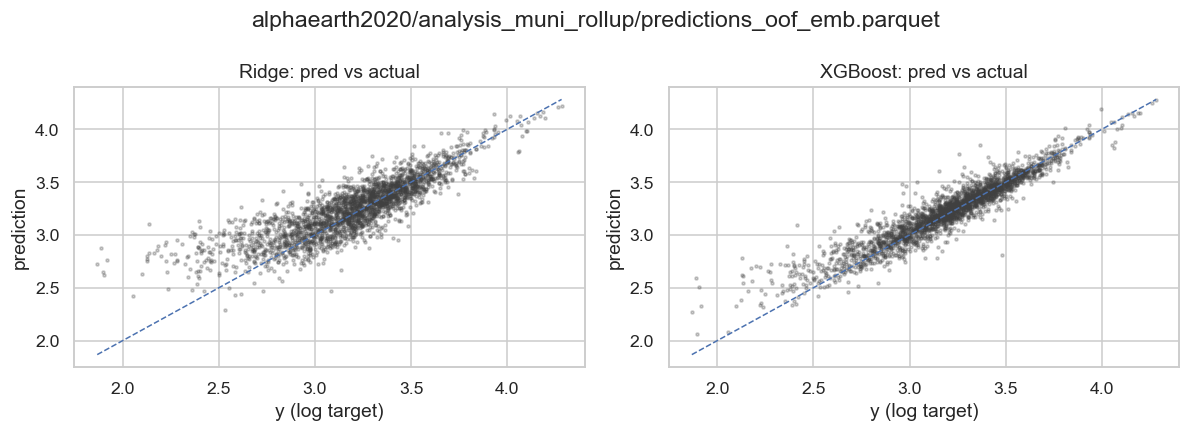

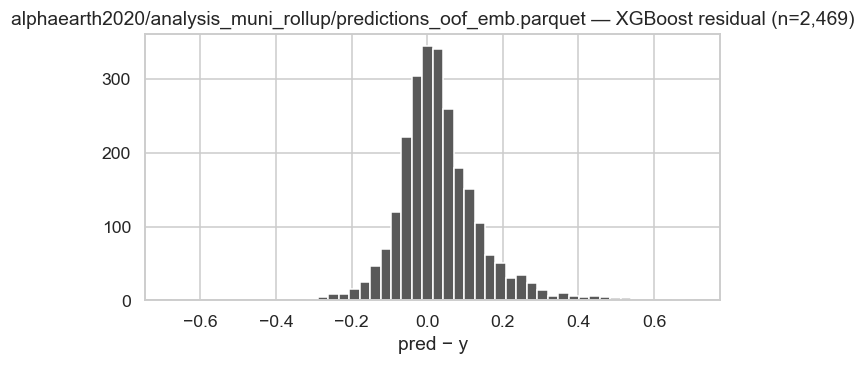

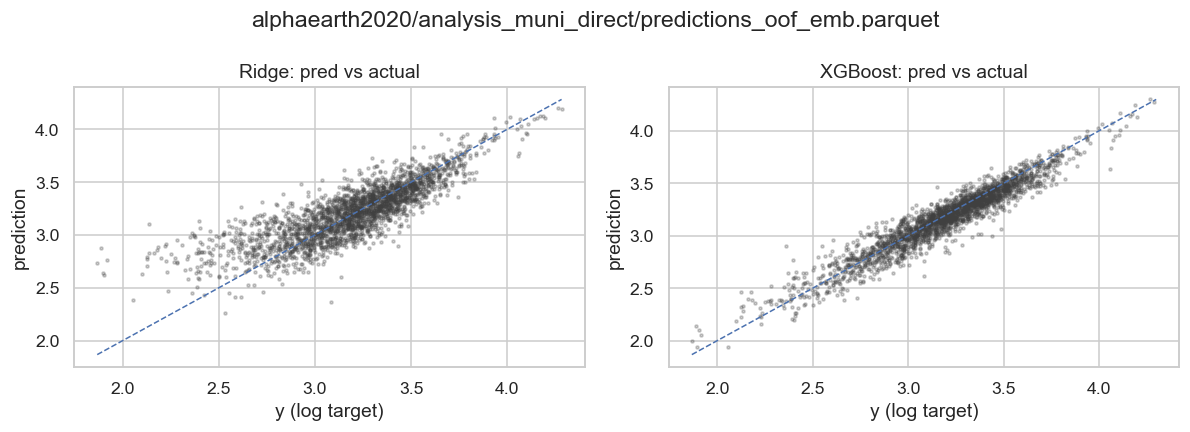

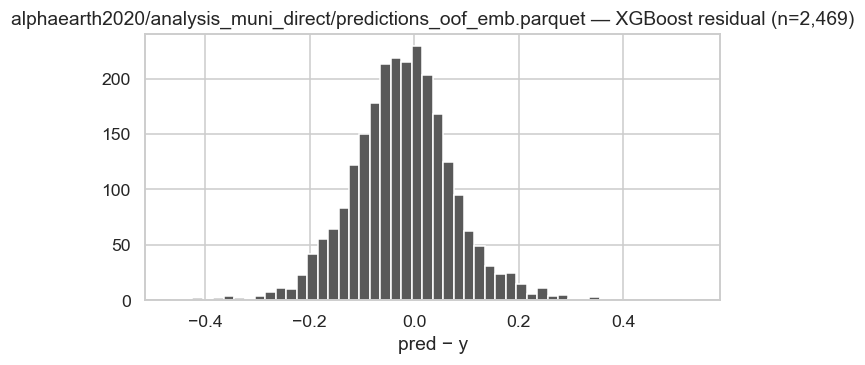


--- Other prediction tables (cross-temporal, etc.) ---


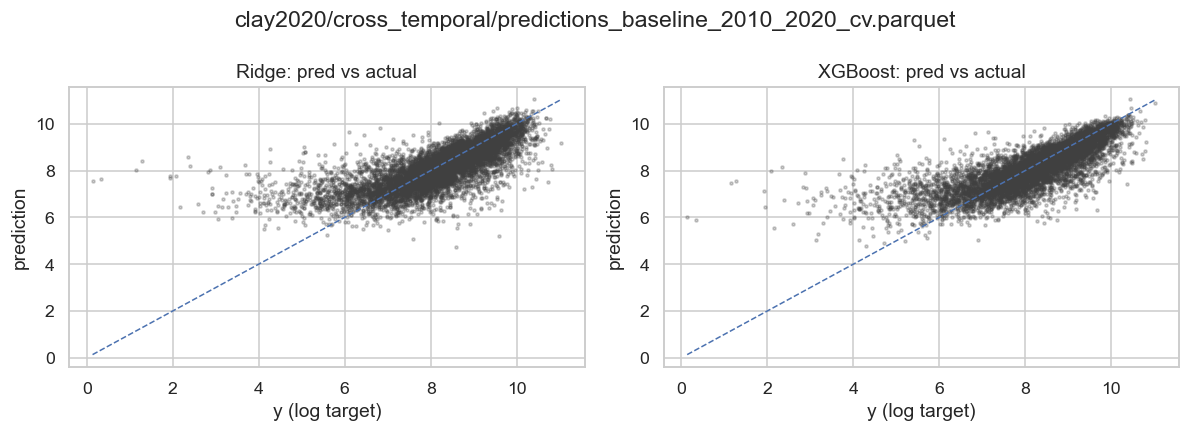

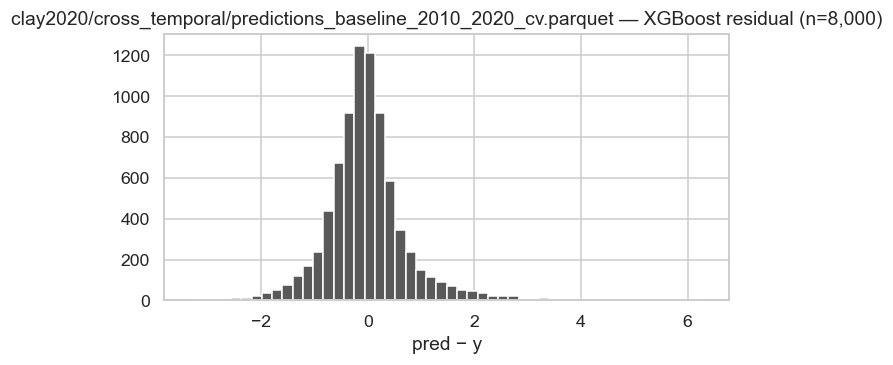

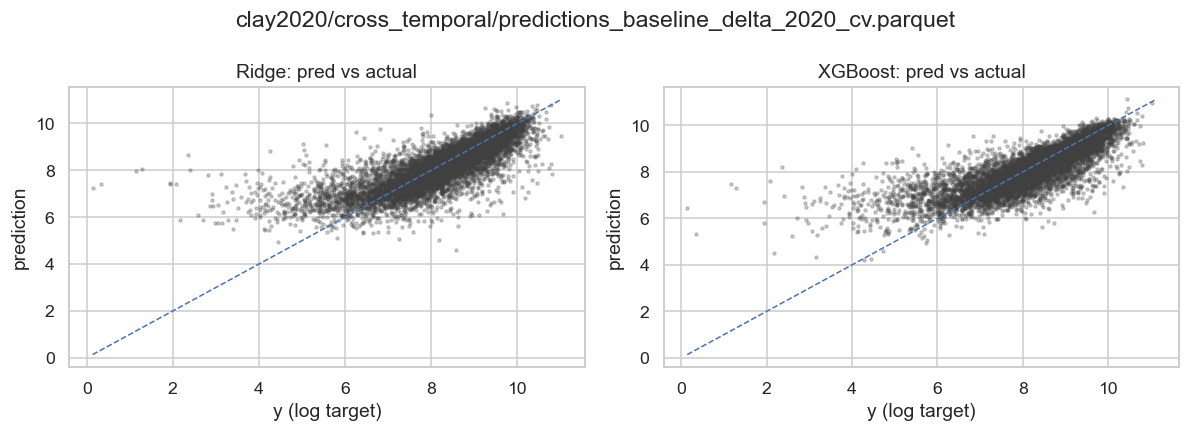

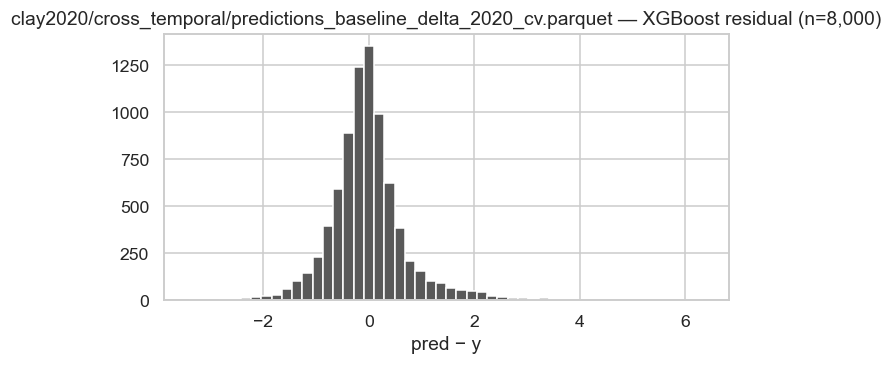

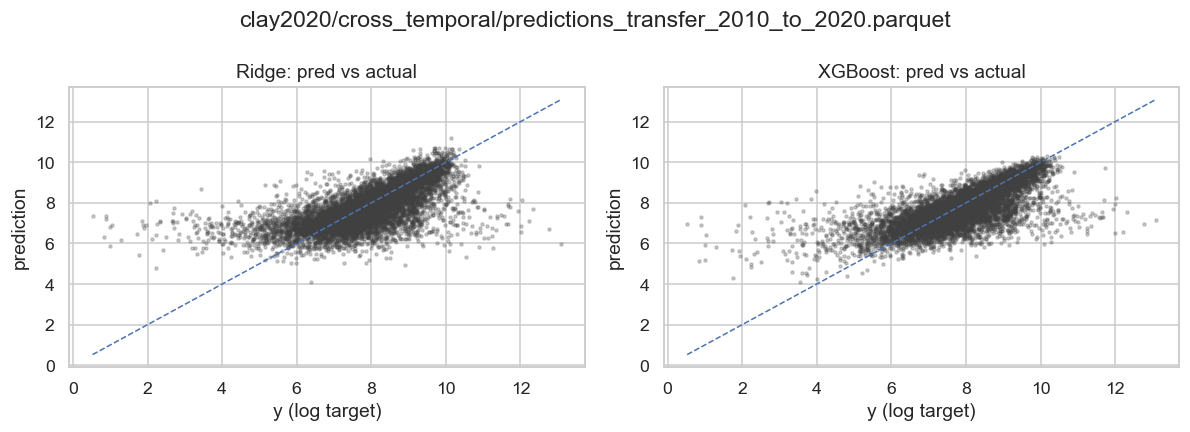

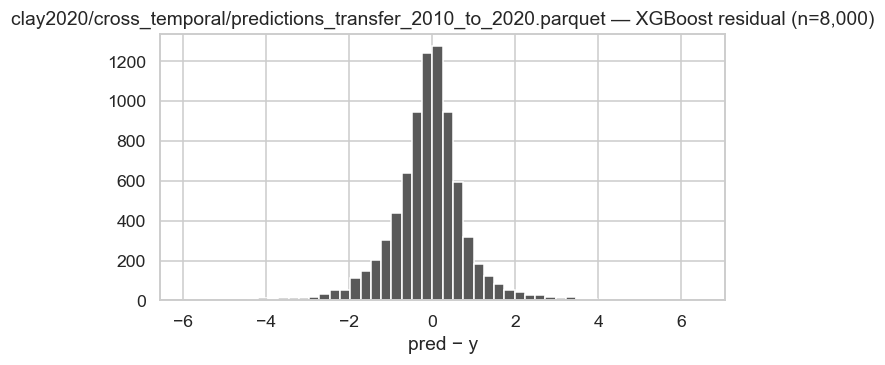

In [20]:
# Prefer OOF prediction parquets for each experiment / analysis
# Set to an int to cap figures (useful for CI / large trees); None = plot all.
PLOT_LIMIT: int | None = None


def _sort_pred_paths(paths: list[Path]) -> list[Path]:
    """Order: known experiments first, then analysis_ageb / muni subdirs, then path."""

    def sort_key(p: Path) -> tuple:
        rel = p.relative_to(RESULTS_DIR)
        parts = rel.parts
        exp = parts[0] if parts else ""
        ana = parts[1] if len(parts) > 1 else ""
        er = EXPERIMENT_ORDER.index(exp) if exp in EXPERIMENT_ORDER else 999
        ar = ANALYSIS_ORDER.index(ana) if ana in ANALYSIS_ORDER else 999
        return (er, ar, str(rel))

    return sorted(paths, key=sort_key)


_oof_raw = [p for p in parquet_paths if p.name.startswith("predictions_oof")]
_oof_set = set(_oof_raw)
oof_paths = _sort_pred_paths(_oof_raw)
other_pred = _sort_pred_paths([p for p in parquet_paths if p not in _oof_set])


def _plot_list(paths: list[Path], heading: str) -> None:
    print(heading)
    for i, p in enumerate(paths):
        if PLOT_LIMIT is not None and i >= PLOT_LIMIT:
            print(f"  ... stopped at PLOT_LIMIT={PLOT_LIMIT}")
            break
        rel = p.relative_to(RESULTS_DIR)
        df = pd.read_parquet(p)
        plot_pred_diagnostics(df, title=str(rel))
        plt.close("all")


_plot_list(oof_paths, "\n--- OOF prediction parquets ---")
_plot_list(other_pred, "\n--- Other prediction tables (cross-temporal, etc.) ---")

## Load all parquets into dictionary

Optional helper to load all predictions into memory. Use with caution due to high memory usage.

In [21]:
def load_all_parquets(base: Path, *, max_rows_preview: int = 3) -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    for p in sorted(base.rglob("*.parquet")):
        key = str(p.relative_to(base))
        out[key] = pd.read_parquet(p)
    print(f"Loaded {len(out)} parquet tables")
    for k, v in out.items():
        print(f"  {k}: shape {v.shape}, columns {list(v.columns)[:12]}{'...' if v.shape[1] > 12 else ''}")
        display(v.head(max_rows_preview))
    return out


# Uncomment to load everything at once:
# all_tables = load_all_parquets(RESULTS_DIR)

## Feature Importance Plots

Loads the embeddings and trains an XGBoost model to extract and plot the top feature importances.

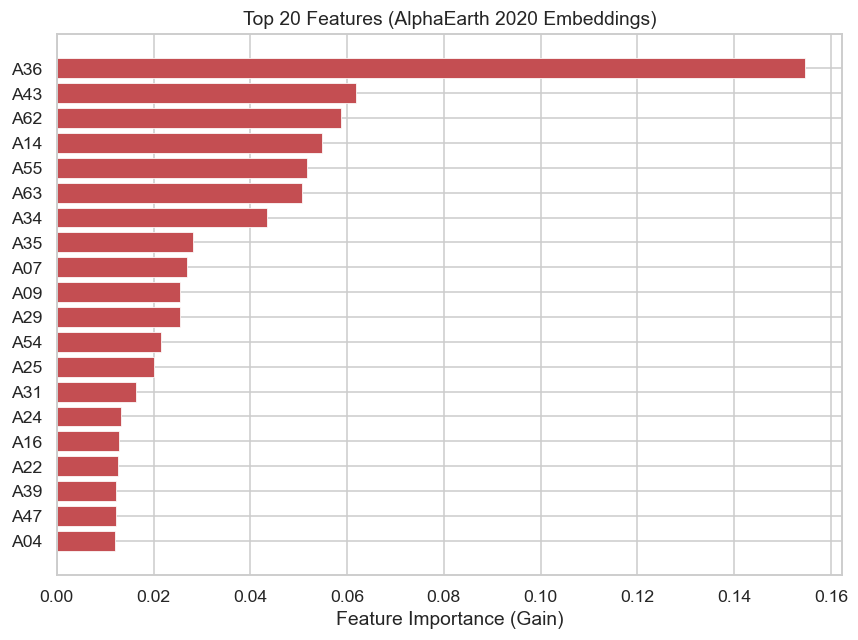

In [22]:
import xgboost as xgb

# Example: Load AlphaEarth 2020 embeddings and train a quick XGBoost model to get feature importances
emb_path = Path("../alphaearth_src/data/embeddings/00_all_mexico_embeddings_combined.csv")
if emb_path.exists():
    df_emb = pd.read_csv(emb_path)
    feature_cols = [c for c in df_emb.columns if c.startswith('A') and c[1:].isdigit()]
    
    # Drop rows with NaNs in target or features
    df_clean = df_emb.dropna(subset=['log_popden'] + feature_cols)
    
    X = df_clean[feature_cols]
    y = df_clean['log_popden']
    
    model = xgb.XGBRegressor(n_estimators=50, max_depth=6, random_state=42)
    model.fit(X, y)
    
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[-20:] # top 20
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(20), importances[sorted_idx], color="#C44E52", edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(20))
    ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
    ax.set_xlabel("Feature Importance (Gain)")
    ax.set_title("Top 20 Features (AlphaEarth 2020 Embeddings)")
    plt.tight_layout()
    plt.show()
else:
    print("AlphaEarth embeddings not found at", emb_path)